# Figures 1-5 (Linear Load + Plot Notebook)

This notebook keeps each figure section linear and readable while using a few shared helpers for repetitive plotting tasks.
- Load existing data files
- Plot
- Save/show with one shared function

No intermediate-data creation and no custom classes.

In [2]:
from pathlib import Path
from itertools import combinations
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import r2_score

repo_root = Path.cwd().resolve()
while not (repo_root / "figures_scripts_notebooks").exists():
    if repo_root.parent == repo_root:
        raise FileNotFoundError("Could not find repository root.")
    repo_root = repo_root.parent

print("Repo root:", repo_root)

save_figures = True
show_figures = True
save_png_dpi = 300

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")

def figure_dir(name: str) -> Path:
    out_dir = repo_root / "images" / name
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def finalize_figure(fig: plt.Figure, output_path: Path | None = None) -> None:
    if save_figures and output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=save_png_dpi, bbox_inches="tight")
    if show_figures:
        plt.show()
    else:
        plt.close(fig)

Repo root: /stor/work/Ellington/bioml/zero_shot_analysis


## Figure 1A
Load summary CSVs and plot side-by-side model comparison.

In [3]:
# clean labels function

def clean_model_name(df):

    # replace 3 sm both with "-3 (hybrid)"
    df["model"] = df["model"].str.replace("ESM3_sm_both", "ESM-3 (hybrid)")
    # replace 3 sm sequence with "-3 (sequence)"
    df["model"] = df["model"].str.replace("ESM3_sm_sequence", "ESM-3 (sequence)")
    # replace 3 sm structure with "-3 (structure)"
    df["model"] = df["model"].str.replace("ESM3_sm_structure", "ESM-3 (structure)")
    # replace ESM2 with "ESM-2"
    df["model"] = df["model"].str.replace("ESM2", "ESM-2")
    # for labels, replace underscore with spaces
    df["model"] = df["model"].str.replace("_", " ")



FireProt proteins plotted after >=20 filter: 39


/tmp/ipykernel_844722/58001941.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)
/tmp/ipykernel_844722/58001941.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


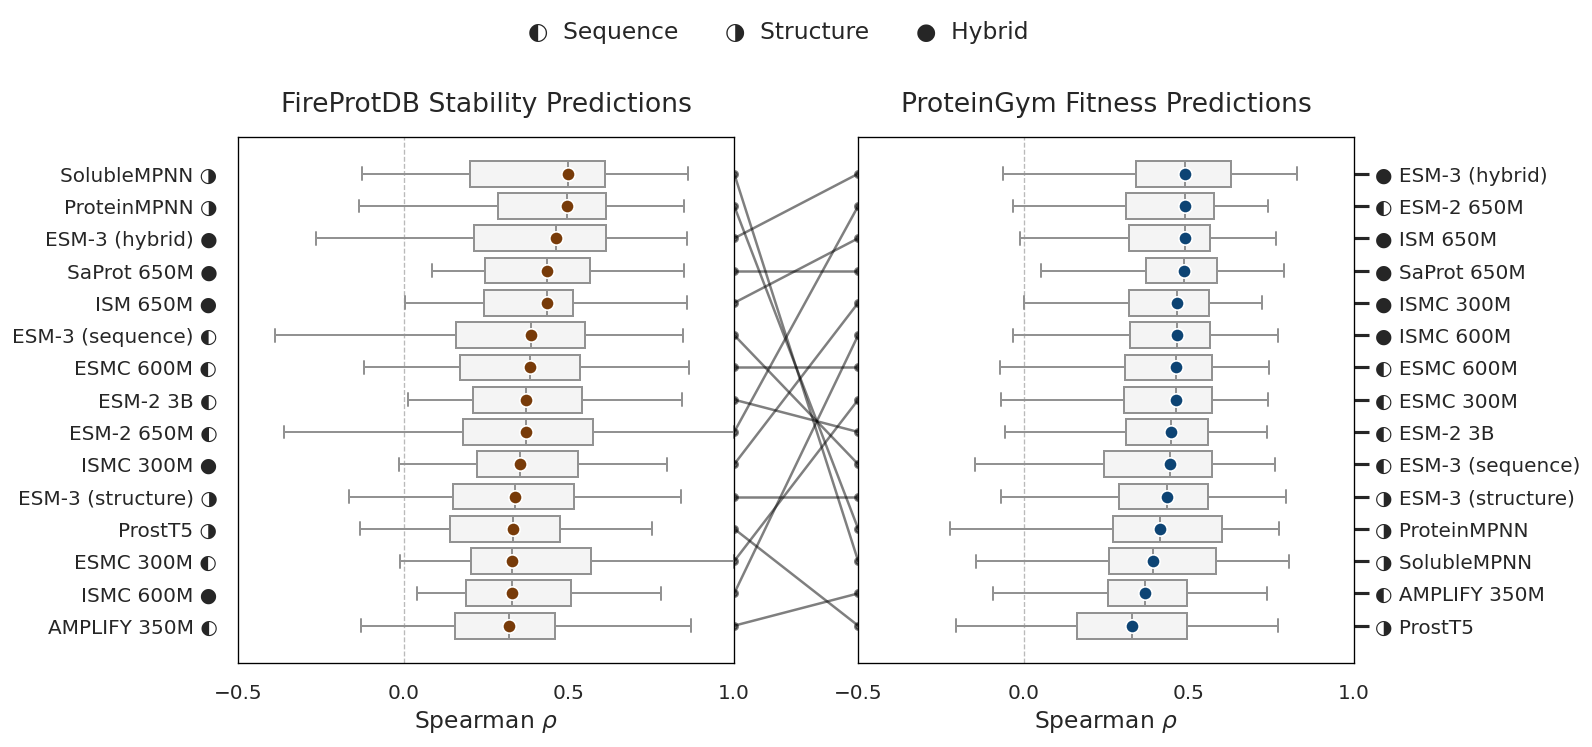

FireProtDB median range: 0.3174977828913634 0.4987179487179487
ProteinGym median range: 0.3265966398675571 0.48853631765469363


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# 1. Define the missing dictionary mapping your models to their types
model_to_type = {
    "SolubleMPNN": "structure",
    "ProteinMPNN": "structure",
    "ESM-3 (hybrid)": "hybrid",
    "SaProt 650M": "hybrid",
    "ISM 650M": "hybrid",
    "ESM-3 (sequence)": "sequence",
    "ESMC 600M": "sequence",
    "ESM-2 3B": "sequence",
    "ESM-2 650M": "sequence",
    "ISMC 300M": "hybrid",
    "ESM-3 (structure)": "structure",
    "ProstT5": "structure",
    "ESMC 300M": "sequence",
    "ISMC 600M": "hybrid",
    "AMPLIFY 350M": "sequence"
}

mut_numb_filt = 20
fpdb_metrics = pd.read_csv(repo_root / "outputs/csvs/fig1_fpdb_comparison_plot.csv")
gym_metrics = pd.read_csv(repo_root / "outputs/csvs/fig1_pg_comparison_plot.csv")
metric_col = "spearman_rho"

# Enforce FireProtDB >=20-mutant filter from individual CSV files before plotting.
fireprot_individual_dir = repo_root / "data/fireprotdb_data/fireprot_csvs/individuals"
eligible_fireprot = set()
for p in fireprot_individual_dir.glob("*.csv"):
    try:
        d = pd.read_csv(p)
    except Exception:
        continue
    if "mutant" in d.columns and d["mutant"].nunique() >= mut_numb_filt:
        eligible_fireprot.add(p.stem)

fpdb_metrics = fpdb_metrics[fpdb_metrics["protein"].isin(eligible_fireprot)].copy()
print(f"FireProt proteins plotted after >={mut_numb_filt} filter: {fpdb_metrics['protein'].nunique()}")

for df in [fpdb_metrics, gym_metrics]:
    clean_model_name(df)

fire_order = fpdb_metrics.groupby("model")[metric_col].median().sort_values(ascending=False).index.tolist()
gym_order = gym_metrics.groupby("model")[metric_col].median().sort_values(ascending=False).index.tolist()

# Create 3 subplots: Left Boxplot, Middle Ladder, Right Boxplot
fig, (ax1, ax_mid, ax2) = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 0.25, 1]}, sharey=False)
fig.subplots_adjust(wspace=0.0, bottom=0.15) 

# Base kwargs for the boxes
box_kwargs = {
    "color": "#F4F4F4", 
    "fliersize": 0, 
    "linewidth": 1.2,
    "showmeans": False
}

median_props_left = {"marker": "o", "markerfacecolor": "#783B09", "markeredgecolor": "#ffffff", "markersize": 8, "zorder": 10}
median_props_right = {"marker": "o", "markerfacecolor": "#0D4474", "markeredgecolor": "#ffffff", "markersize": 8, "zorder": 10}

# Left Plot (FireProtDB)
ax1.axvline(x=0, color="darkgrey", linestyle="--", alpha=0.8, zorder=0, linewidth=0.8)
sns.boxplot(data=fpdb_metrics, x=metric_col, y="model", order=fire_order, ax=ax1, **box_kwargs)

left_medians = fpdb_metrics.groupby("model")[metric_col].median().reindex(fire_order)
ax1.plot(left_medians, range(len(fire_order)), linestyle="none", **median_props_left)

ax1.set_xlabel("Spearman $\\rho$", fontsize=14, fontweight='medium')
ax1.set_ylabel("")
ax1.set_xlim(-0.5, 1)
ax1.set_title("FireProtDB Stability Predictions", fontsize=16, pad=15)
ax1.tick_params(axis='both', labelsize=12)

# Right Plot (ProteinGym)
ax2.axvline(x=0, color="darkgrey", linestyle="--", alpha=0.8, zorder=0, linewidth=0.8)
sns.boxplot(data=gym_metrics, x=metric_col, y="model", order=gym_order, ax=ax2, **box_kwargs)

right_medians = gym_metrics.groupby("model")[metric_col].median().reindex(gym_order)
ax2.plot(right_medians, range(len(gym_order)), linestyle="none", **median_props_right)

ax2.set_xlabel("Spearman $\\rho$", fontsize=14, fontweight='medium')
ax2.set_ylabel("")
ax2.set_xlim(-0.5, 1)
ax2.set_title("ProteinGym Fitness Predictions", fontsize=16, pad=15)
ax2.tick_params(axis='both', labelsize=12)
ax2.yaxis.tick_right()

# Add symbols to model labels based on type
type_symbols = {"sequence": "◐", "structure": "◑", "hybrid": "●"}

def add_symbols_to_ticks(ax, left=False):
    new_labels = []
    for label in ax.get_yticklabels():
        model_name = label.get_text()
        m_type = model_to_type.get(model_name, "sequence") 
        symbol = type_symbols.get(m_type, "")
        if left is True:
            new_labels.append(f"{symbol} {model_name}")
        else:
            new_labels.append(f"{model_name} {symbol}")
    ax.set_yticklabels(new_labels)

add_symbols_to_ticks(ax1, left=False)
add_symbols_to_ticks(ax2, left=True)

# Middle Ladder Plot
ax_mid.set_xlim(0, 1)
ax_mid.set_ylim(ax1.get_ylim()) 
ax_mid.axis('off') 
ax_mid.set_xticks([]) # Force remove overlapping x ticks
ax_mid.set_yticks([]) # Force remove overlapping y ticks

# Draw the connecting lines
for model in fire_order:
    y_left = fire_order.index(model)
    y_right = gym_order.index(model)
    ax_mid.plot([0, 1], [y_left, y_right], color="black", alpha=0.5, linewidth=1.5)
    ax_mid.scatter([0, 1], [y_left, y_right], color="black", alpha=0.5, s=15, zorder=3)

# Add a box around the outer plots
for spine in ["top", "right", "bottom", "left"]:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_color("black")
    ax1.spines[spine].set_linewidth(0.8)
    
    ax2.spines[spine].set_visible(True)
    ax2.spines[spine].set_color("black")
    ax2.spines[spine].set_linewidth(0.8)

# Formatting ticks and grids
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax1.grid(False)
ax2.grid(False)

# Add a text-only legend outside the plots (centered at the bottom)
legend_elements = [
    mpatches.Patch(color='none', label=f"{symbol}  {m_type.capitalize()}") 
    for m_type, symbol in type_symbols.items()
]

fig.legend(
    handles=legend_elements, 
    loc="lower center", 
    bbox_to_anchor=(0.5, 0.98), 
    ncol=3, 
    handlelength=0, 
    handletextpad=0, 
    frameon=False, 
    fontsize=14
)

finalize_figure(fig, figure_dir("figure1") / "comparison_plot.png")

# print min and max median for each dataset
print("FireProtDB median range:", left_medians.min(), left_medians.max())
print("ProteinGym median range:", right_medians.min(), right_medians.max())

In [13]:
# count all mutations in the FireProtDB dataset after filtering
total_mutations = 0
for p in fireprot_individual_dir.glob("*.csv"):
    try:
        d = pd.read_csv(p)
    except Exception:
        continue
    if "mutant" in d.columns and d["mutant"].nunique() >= mut_numb_filt:
        total_mutations += d["mutant"].nunique()
print(f"Total mutations in FireProtDB after >={mut_numb_filt} filter: {total_mutations}")


Total mutations in FireProtDB after >=20 filter: 5920
Total mutations in ProteinGym after >=20 filter: 0


In [27]:

pgym_dir = repo_root / "data/proteingym_data/DMS_ProteinGym_substitutions"

# count all mutations in the ProteinGym dataset after filtering
total_mutations = 0
for p in pgym_dir.glob("*.csv"):
    try:
        d = pd.read_csv(p)
    except Exception:
        continue
    if "mutant" in d.columns and d["mutant"].nunique() >= mut_numb_filt:
        total_mutations += d["mutant"].nunique()
print(f"Total mutations in ProteinGym after >={mut_numb_filt} filter: {total_mutations}")


Total mutations in Pgym after >=20 filter: 2465767


In [28]:
# count files in pgym_dir
total_files = len(list(pgym_dir.glob("*.csv")))
print(f"Total files in ProteinGym directory: {total_files}")

Total files in ProteinGym directory: 217


In [25]:
# count all mutations in the ProteinGym dataset
protein_gym_mutations = pd.read_csv(repo_root / "data/proteingym_data/DMS_substitutions.csv")

# sum DMS_total_number_mutants column
total_gym_mutations = protein_gym_mutations["DMS_total_number_mutants"].sum()
print(f"Total mutations in ProteinGym: {total_gym_mutations}")

# count rows in the metrics CSV files
print(f"Total rows in ProteinGym metrics CSV: {len(protein_gym_mutations)}")

Total mutations in ProteinGym: 2465767
Total rows in ProteinGym metrics CSV: 217


## Figure 1B and 1C
Load summary CSVs and plot paired inter-model comparisons (similar panel style).

FireProt proteins plotted after >=20 filter: 39


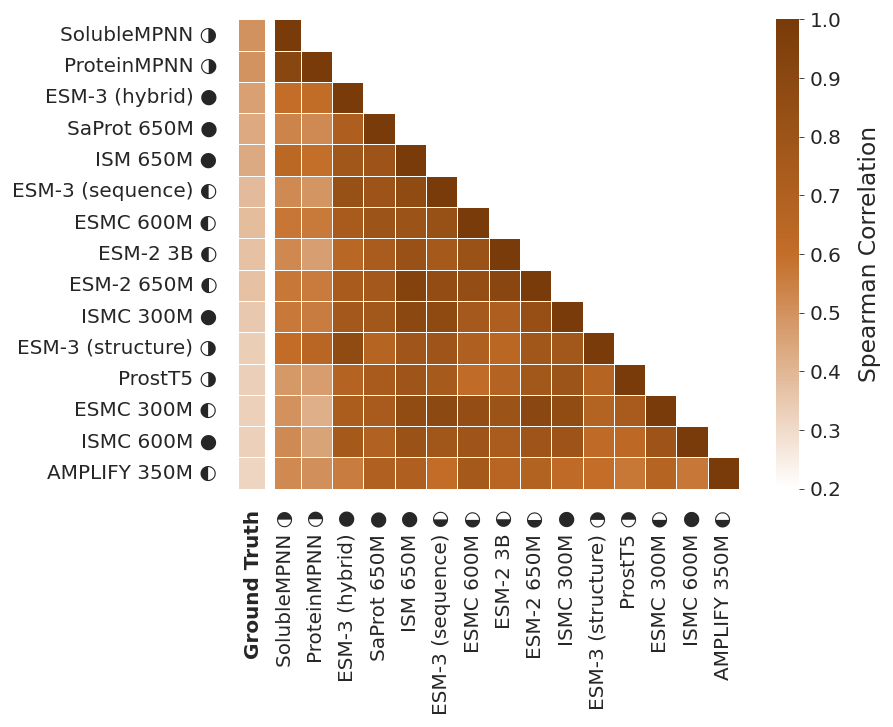

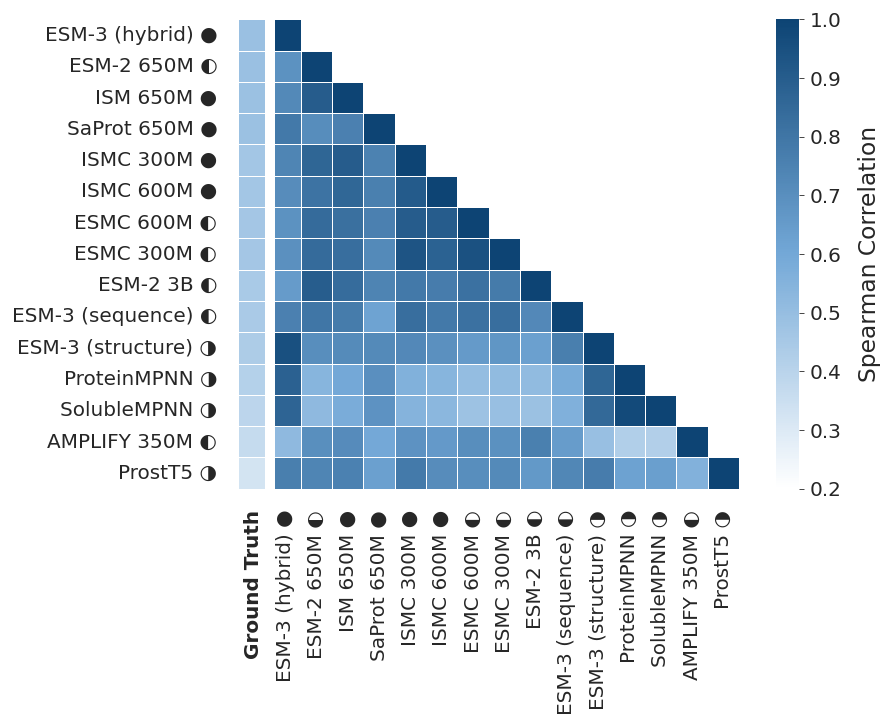

FireProtDB correlation range: -0.6113663698981229 1.0
ProteinGym correlation range: -0.3578623437390977 0.8276965140123035


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

def add_symbols_to_xticks(ax, left=False):
    new_labels = []
    for label in ax.get_xticklabels():
        if label.get_text() == "Ground Truth":
            new_labels.append(label.get_text())
            continue
        model_name = label.get_text()
        m_type = model_to_type.get(model_name, "sequence") 
        symbol = type_symbols.get(m_type, "")
        if left is True:
            new_labels.append(f"{symbol} {model_name}")
        else:
            new_labels.append(f"{model_name} {symbol}")
    ax.set_xticklabels(new_labels)


fpdb_metrics = pd.read_csv(repo_root / "outputs/csvs/fig1_fpdb_comparison_plot.csv")
gym_metrics = pd.read_csv(repo_root / "outputs/csvs/fig1_pg_comparison_plot.csv")
metric_col = "spearman_rho"


# Enforce FireProtDB >=20-mutant filter from individual CSV files before plotting.
fireprot_individual_dir = repo_root / "data/fireprotdb_data/fireprot_csvs/individuals"
eligible_fireprot = set()
for p in fireprot_individual_dir.glob("*.csv"):
    try:
        d = pd.read_csv(p)
    except Exception:
        continue
    if "mutant" in d.columns and d["mutant"].nunique() >= mut_numb_filt:
        eligible_fireprot.add(p.stem)

fpdb_metrics = fpdb_metrics[fpdb_metrics["protein"].isin(eligible_fireprot)].copy()
print(f"FireProt proteins plotted after >={mut_numb_filt} filter: {fpdb_metrics['protein'].nunique()}")

for df in [fpdb_metrics, gym_metrics]:
    clean_model_name(df)

def plot_model_heatmap(
    metrics_df: pd.DataFrame, 
    title: str, 
    output_name: str, 
    cmap,
    metric_name: str = "spearman_rho"
) -> None:
    # Calculate performance against ground truth for each model
    ground_truth_rho = metrics_df.groupby("model")[metric_name].median().sort_values(ascending=False)
    model_order = ground_truth_rho.index.tolist()
    N = len(model_order)

    # Pivot so rows are proteins and columns are models
    pivot_df = metrics_df.pivot_table(index="protein", columns="model", values=metric_name, aggfunc="median")
    
    # Calculate the Spearman correlation matrix between models only
    corr_matrix = pivot_df.corr(method="spearman").loc[model_order, model_order]

    # Prepend Ground Truth as the first column
    heatmap_df = pd.DataFrame(index=model_order)
    heatmap_df["Ground Truth"] = ground_truth_rho
    heatmap_df = pd.concat([heatmap_df, corr_matrix], axis=1)

    # Create mask: fully visible for Ground Truth (col 0), upper triangle for models
    model_mask = np.triu(np.ones((N, N), dtype=bool), k=1)
    gt_mask = np.zeros((N, 1), dtype=bool)
    full_mask = np.hstack([gt_mask, model_mask])

    # Slightly increased width to accommodate the extra column and visual gap
    fig, ax = plt.subplots(figsize=(8.5, 6.4))

    ax.grid(False)
    ax.set_facecolor("white")

    sns.heatmap(
        heatmap_df, 
        mask=full_mask,
        cmap=cmap, 
        vmax=1.0, 
        vmin=0.2, 
        annot=False, 
        square=True, 
        linewidths=0.5, 
        cbar_kws={"shrink": 1, "label": "Spearman Correlation"},
        ax=ax
    )

    # Create the visual separation gap after the first column
    ax.axvline(x=1, color="white", linewidth=6)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12, length=3, width=0.5)
    cbar.set_label("Spearman Correlation", fontsize=14, labelpad=10)

    ax.set_ylabel("")
    ax.set_xlabel("")
    
    ax.tick_params(axis="x", rotation=90, labelsize=12)
    ax.tick_params(axis="y", rotation=0, labelsize=12)

    add_symbols_to_ticks(ax, left=False)
    # add to the x axis labels as well
    add_symbols_to_xticks(ax, left=False)

    # Bold the "Ground Truth" label on x-axis
    for tick in ax.get_xticklabels():
        if tick.get_text() == "Ground Truth":
            tick.set_fontweight("bold")

    plt.setp(ax.get_xticklabels(), ha="center", rotation_mode="default")

    plt.tight_layout()
    finalize_figure(fig, figure_dir("figure1") / output_name)

# make custom heatmaps from #BF5700 and #337AB7 for each
# fireprot_cmap = sns.light_palette("#BF5700", as_cmap=True)
# protgym_cmap = sns.light_palette("#337AB7", as_cmap=True)
fireprot_cmap = sns.light_palette("#A7530E", as_cmap=True)
# protgym_cmap = sns.light_palette("#0D5595", as_cmap=True)
# make the scale light, the color, then dark, so the heatmap is mostly light with pops of color at the higher correlations
# fireprot_cmap = mcolors.LinearSegmentedColormap.from_list("fireprot_cmap", ["#FFFFFF", "#DF8E4C", "#BF5700"])
fireprot_cmap = mcolors.LinearSegmentedColormap.from_list("fireprot_cmap", ["#FFFFFF", "#C36D28", "#783B09"])
protgym_cmap = mcolors.LinearSegmentedColormap.from_list("protgym_cmap", ["#FFFFFF", "#73A8D7", "#0D4474"])

# make one colorbar from #BF5700 and #337AB7 that can be shared across both heatmaps
# combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_cmap", ["#BF5700", "#ffffff", "#337AB7"])

# Generate FireProtDB Heatmap (Orange)
plot_model_heatmap(
    metrics_df=fpdb_metrics,
    title="FireProtDB Stability Predictions",
    output_name="heatmap_comparison_fireprotdb.png",
    cmap=fireprot_cmap,
    metric_name=metric_col
)

# Generate ProteinGym Heatmap (Blue)
plot_model_heatmap(
    metrics_df=gym_metrics,
    title="ProteinGym Fitness Predictions",
    output_name="heatmap_comparison_proteingym.png",
    cmap=protgym_cmap,
    metric_name=metric_col
)

# print min and max correlation across all datasets for FireProtDB and ProteinGym
print("FireProtDB correlation range:", fpdb_metrics[metric_col].min(), fpdb_metrics[metric_col].max())
print("ProteinGym correlation range:", gym_metrics[metric_col].min(), gym_metrics[metric_col].max())

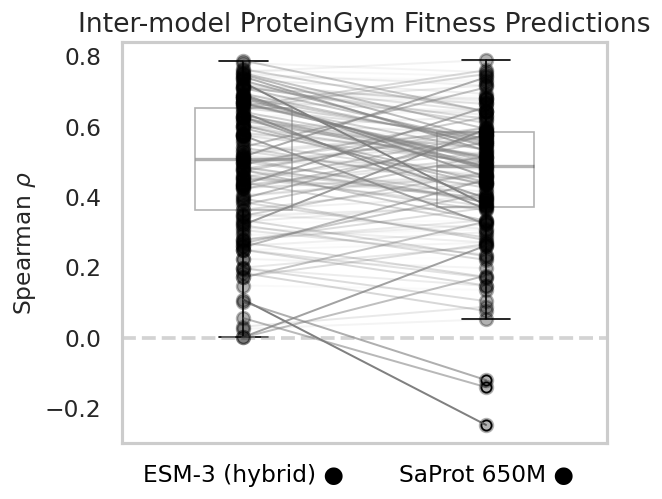

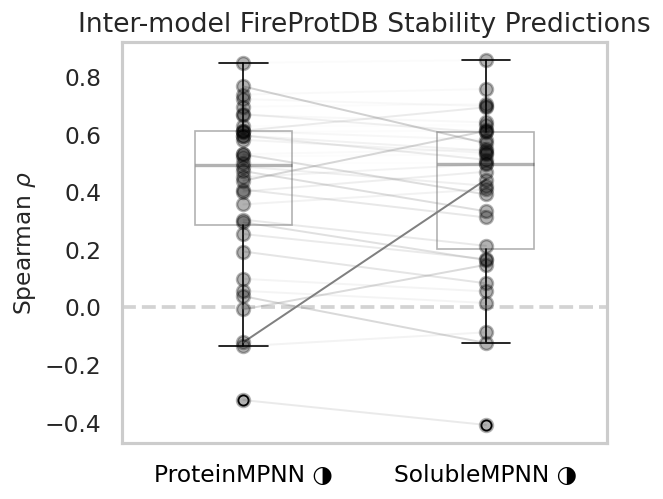

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_figure1_intermodel(fpdb_metrics: pd.DataFrame, gym_metrics: pd.DataFrame, model0: str, model1: str, database: str, show_figures: bool = True):
    repo_root = Path.cwd().resolve()
    metric_col = "spearman_rho"
    
    # type_symbols = {"sequence": "◐", "structure": "◑", "hybrid": "●"}

    model_labels = {
        "ESM3_sm_both": "ESM-3 (hybrid) ●",
        "SaProt_650M": "SaProt 650M ●",
        "ESM-3 (hybrid)": "ESM-3 (hybrid) ●",
        "SaProt 650M": "SaProt 650M ●",
        "SolubleMPNN": "SolubleMPNN ◑",
        "ProteinMPNN": "ProteinMPNN ◑"
    }

    model_colors = {
        "ESM-3 (hybrid) ●": "#000000",
        "SaProt 650M ●": "#000000",
        "SolubleMPNN ◑": "#000000",
        "ProteinMPNN ◑": "#000000"
    }

    fpdb_metrics = fpdb_metrics.copy()
    gym_metrics = gym_metrics.copy()
    fpdb_metrics["model"] = fpdb_metrics["model"].replace(model_labels)
    gym_metrics["model"] = gym_metrics["model"].replace(model_labels)

    if database == "fireprotdb":
        group0 = fpdb_metrics[fpdb_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = fpdb_metrics[fpdb_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model FireProtDB Stability Predictions"
    else:
        group0 = gym_metrics[gym_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = gym_metrics[gym_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model ProteinGym Fitness Predictions"

    common = group0.index.intersection(group1.index)
    group0 = group0.loc[common]
    group1 = group1.loc[common]

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    pos0, pos1 = 1, 2
    
    ax.boxplot(group0, positions=[pos0], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))
    ax.boxplot(group1, positions=[pos1], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))

    diffs = np.abs(group1 - group0)
    diff_min, diff_max = diffs.min(), diffs.max()
    denom = max(diff_max - diff_min, 1e-9)
    
    for cat in common:
        y0 = float(group0.loc[cat])
        y1 = float(group1.loc[cat])
        alpha = float(np.clip(0.01 + (1.0 - 0.01) * (diffs.loc[cat] - diff_min) / denom, 0.01, 1.0))
        ax.scatter([pos0], [y0], color="black", zorder=5, alpha=0.3, s=60)
        ax.scatter([pos1], [y1], color="black", zorder=5, alpha=0.3, s=60)
        ax.plot([pos0, pos1], [y0, y1], color="gray", alpha=alpha, linewidth=1.2, zorder=4)

    ax.set_xticks([pos0, pos1])
    ax.set_xticklabels([model0, model1], fontsize=14)
    
    for ticklabel, color in zip(ax.get_xticklabels(), [model_colors.get(model0, "black"), model_colors.get(model1, "black")]):
        ticklabel.set_color(color)

    ax.set_ylabel("Spearman $\\rho$", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0.5, 2.5)
    ax.tick_params(labelsize=14)
    ax.axhline(y=0, color="darkgrey", linestyle="--", alpha=0.5)
    plt.tight_layout()
    # remove gridlines
    ax.grid(False)

    # save the figure
    output_path = figure_dir("figure1") / f"intermodel_comparison_{database}.png"
    if save_figures:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=save_png_dpi, bbox_inches="tight")

    if show_figures:
        plt.show()
    else:
        plt.close(fig)

# Execution call
plot_figure1_intermodel(
    fpdb_metrics, 
    gym_metrics, 
    "ESM-3 (hybrid) ●", 
    "SaProt 650M ●", 
    "proteingym"
)

plot_figure1_intermodel(
    fpdb_metrics, 
    gym_metrics, 
    "ProteinMPNN ◑", 
    "SolubleMPNN ◑", 
    "fireprotdb"
)

NameError: name 'GLOBAL_CONFIG' is not defined

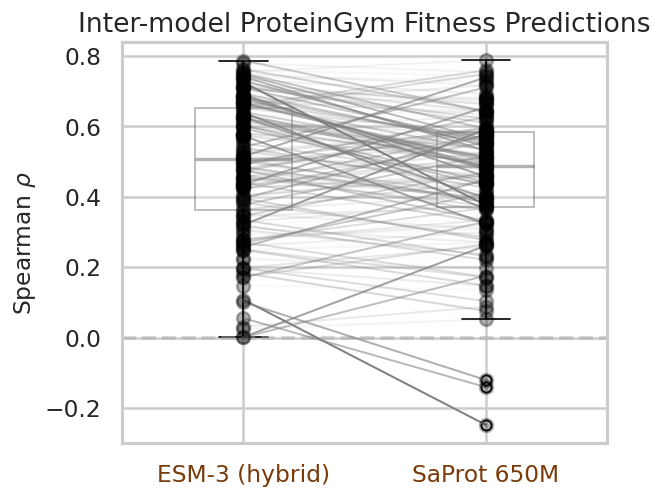

In [10]:
REPO_ROOT = Path.cwd().resolve()
MODEL_LABELS = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
    "SaProt_650M": "SaProt 650M",
    "ISM_650M": "ISM 650M",
    "ISMC_300M": "ISMC 300M",
    "ISMC_600M": "ISMC 600M",
    "ProstT5": "ProstT5",
    "AMPLIFY_350M": "AMPLIFY 350M"
}

MODEL_COLORS = {
    "ESM-3 (hybrid)": "#783B09",
    "SaProt 650M": "#783B09",
    "ISM 650M": "#783B09",
    "ISMC 300M": "#783B09",
    "ISMC 600M": "#783B09",
    "ESM-3 (sequence)": "#0D4474",
    "ESM-2 3B": "#0D4474",
    "ESM-2 650M": "#0D4474",
    "ESM-3 (structure)": "#0D4474",
    "ProstT5": "#0D4474",
    "AMPLIFY 350M": "#0D4474",
    "SolubleMPNN": "#A7530E",
    "ProteinMPNN": "#A7530E"
}

FIG1 = {
    "fpdb_csv": REPO_ROOT / "outputs/csvs/fig1_fpdb_comparison_plot.csv",
    "proteingym_csv": REPO_ROOT / "outputs/csvs/fig1_pg_comparison_plot.csv",
    "out_dir": REPO_ROOT / "images/figure1",
    "comparison_figsize": (9, 6),
    "comparison_wspace": 0.25,
    "xlim": (-1, 1),
    "metric_col": "spearman_rho",
    "intermodel_pairs": [
        ("ESM-3 (hybrid)", "SaProt 650M", "proteingym"),
        ("ProteinMPNN", "SolubleMPNN", "fireprotdb"),
    ],
}

def plot_figure1_intermodel(fpdb_metrics: pd.DataFrame, gym_metrics: pd.DataFrame, model0: str, model1: str, database: str, cfg: dict):
    fpdb_metrics = fpdb_metrics.copy()
    gym_metrics = gym_metrics.copy()
    fpdb_metrics["model"] = fpdb_metrics["model"].replace(MODEL_LABELS)
    gym_metrics["model"] = gym_metrics["model"].replace(MODEL_LABELS)

    metric_col = cfg["metric_col"]
    if database == "fireprotdb":
        group0 = fpdb_metrics[fpdb_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = fpdb_metrics[fpdb_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model FireProtDB Stability Predictions"
        out_name = f"inter-model_comparison_plot_fireprotdb_{model0.replace(' ', '_')}_{model1.replace(' ', '_')}"
    else:
        group0 = gym_metrics[gym_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = gym_metrics[gym_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model ProteinGym Fitness Predictions"
        out_name = f"inter-model_comparison_plot_proteingym_{model0.replace(' ', '_')}_{model1.replace(' ', '_')}"

    common = group0.index.intersection(group1.index)
    group0 = group0.loc[common]
    group1 = group1.loc[common]

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    pos0, pos1 = 1, 2
    ax.boxplot(group0, positions=[pos0], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))
    ax.boxplot(group1, positions=[pos1], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))

    diffs = np.abs(group1 - group0)
    diff_min, diff_max = diffs.min(), diffs.max()
    denom = max(diff_max - diff_min, 1e-9)
    for cat in common:
        y0 = float(group0.loc[cat])
        y1 = float(group1.loc[cat])
        alpha = float(np.clip(0.01 + (1.0 - 0.01) * (diffs.loc[cat] - diff_min) / denom, 0.01, 1.0))
        ax.scatter([pos0], [y0], color="black", zorder=5, alpha=0.3, s=60)
        ax.scatter([pos1], [y1], color="black", zorder=5, alpha=0.3, s=60)
        ax.plot([pos0, pos1], [y0, y1], color="gray", alpha=alpha, linewidth=1.2, zorder=4)

    ax.set_xticks([pos0, pos1])
    ax.set_xticklabels([model0, model1], fontsize=14)
    for ticklabel, color in zip(ax.get_xticklabels(), [MODEL_COLORS.get(model0, "black"), MODEL_COLORS.get(model1, "black")]):
        ticklabel.set_color(color)

    ax.set_ylabel("Spearman $\\rho$", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0.5, 2.5)
    ax.tick_params(labelsize=14)
    ax.axhline(y=0, color="darkgrey", linestyle="--", alpha=0.5)
    plt.tight_layout()

    # save_figure(fig, cfg["out_dir"] / out_name, GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)

plot_figure1_intermodel(
    fpdb_metrics, 
    gym_metrics, 
    "ESM-3 (hybrid)", 
    "SaProt 650M", 
    "proteingym", 
    {"metric_col": metric_col}
)

## Figure 2
Load ProteinGym groups + substitution CSVs, then plot inter-phenotype and inter-experimenter panels.

In [6]:
# replacement dictionary for group names
name_replacements = {
    "Proto-oncogene tyrosine-protein kinase Src": "Src Kinase",
    "Vitamin K epoxide reductase complex subunit 1": "VitK epoxide reductase",
    "Immunoglobulin G-binding protein G": "Protein G",
    "Ubiquitin-ribosomal protein": "Ubiquitin RL40A",
    # "Solute carrier 22A1": "SLC22A1",
    "Spike glycoprotein": "Spike glycoprotein",
    "Beta-lactamase TEM": "TEM-1 Beta-lactamase",
    "Potassium channel E1": "K-Channel E1",
    "Potassium channel J1": "K-Channel J1",
    "Cytochrome P450": "Cytochrome P450",
    "p53": "Tumor Protein p53"
}


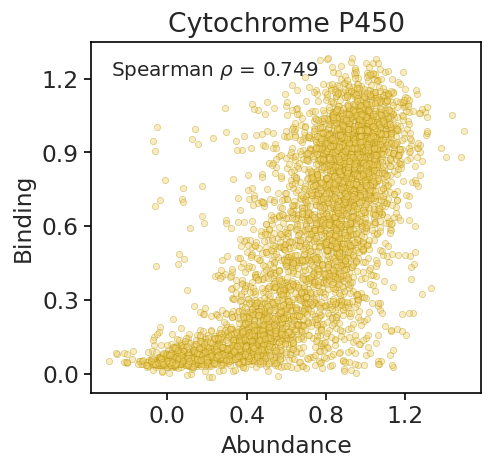

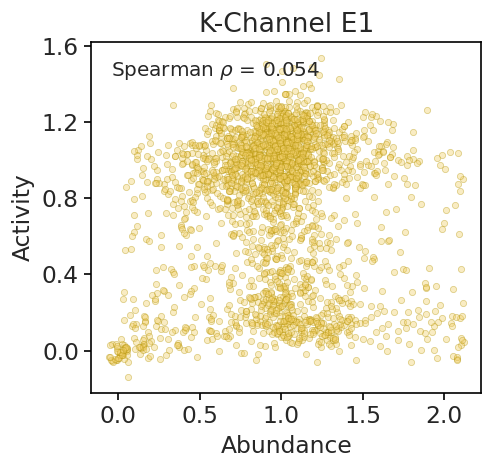

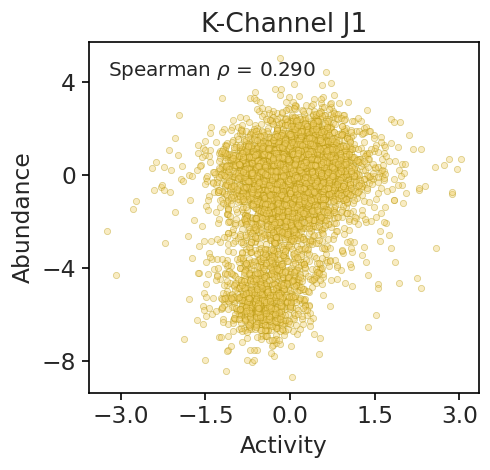

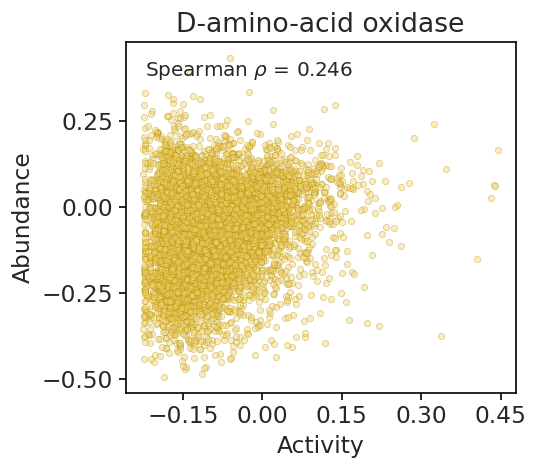

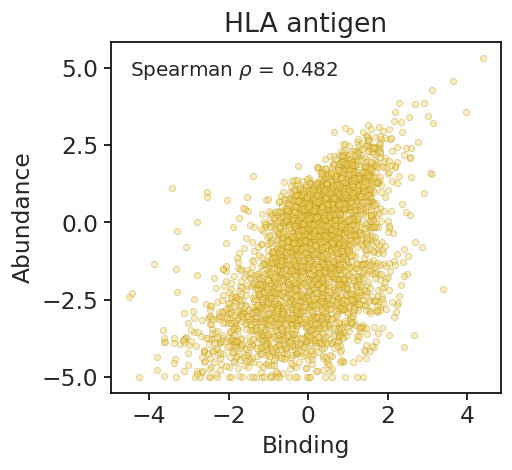

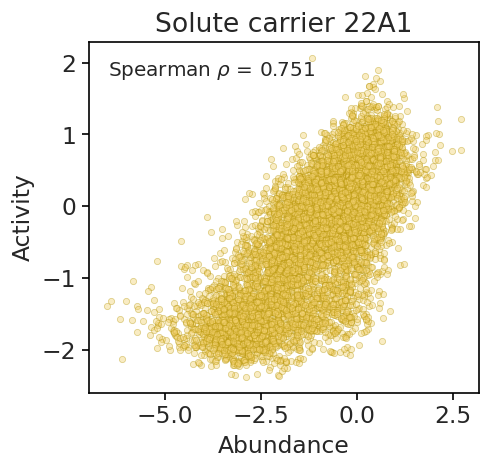

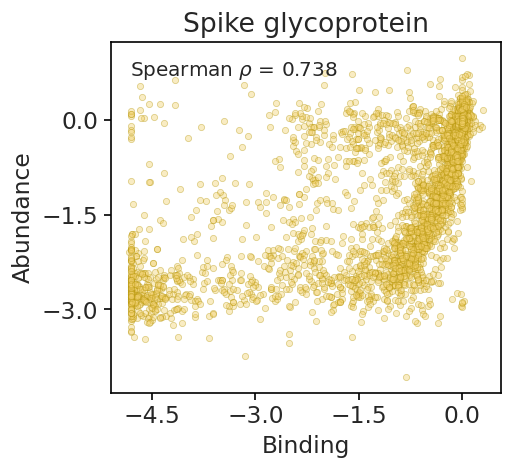

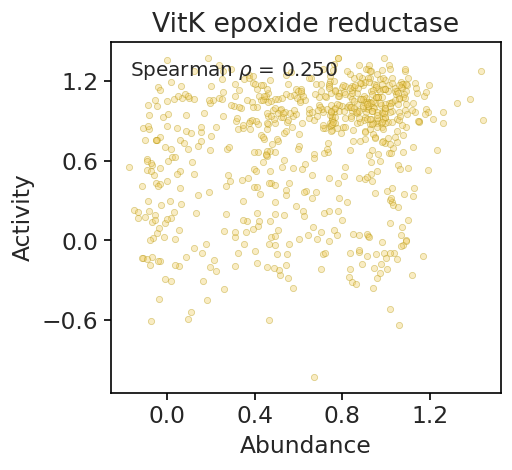

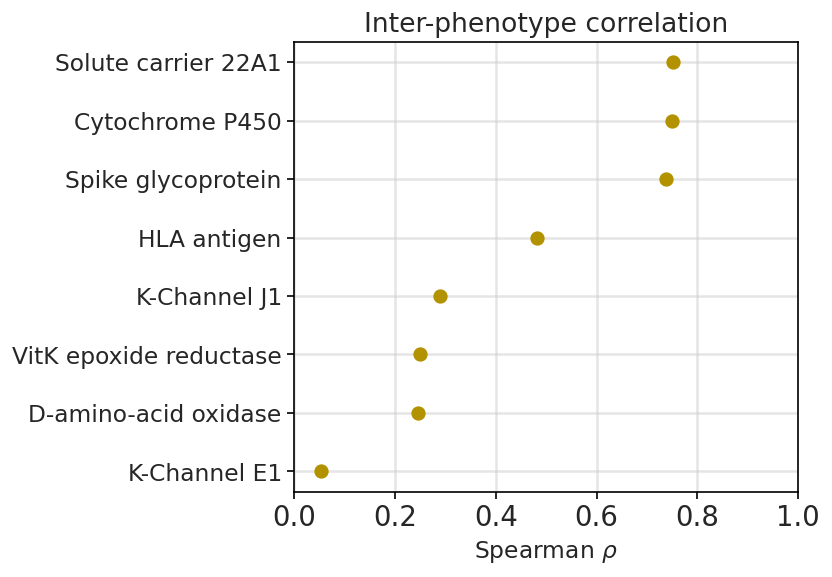

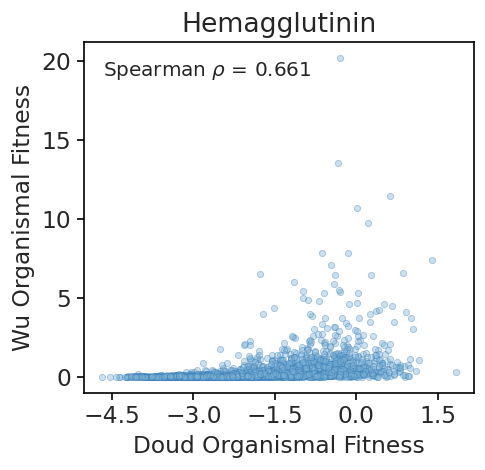

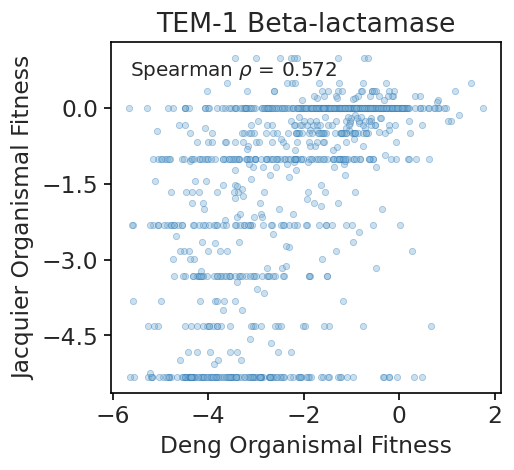

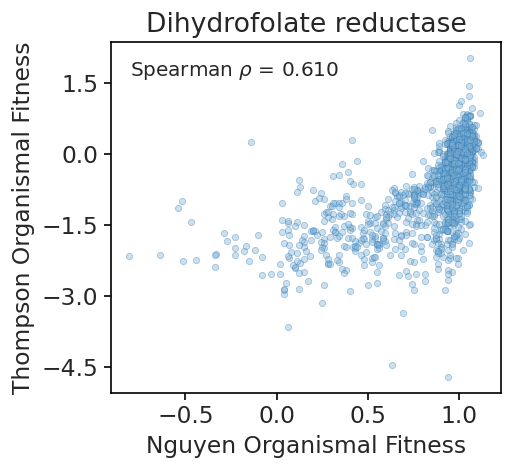

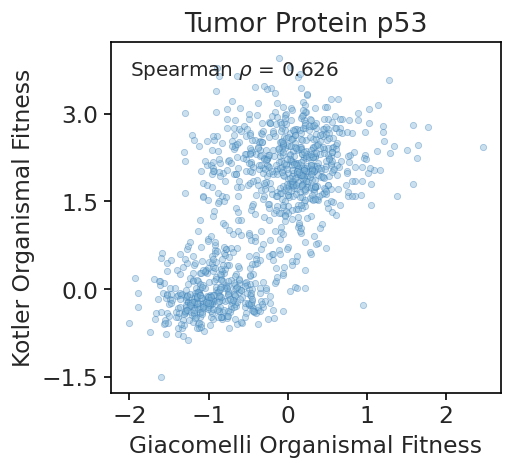

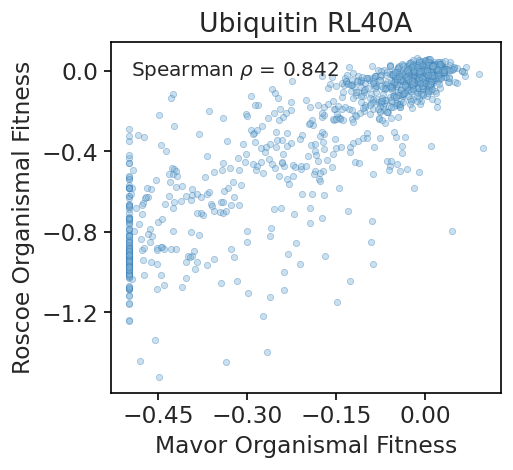

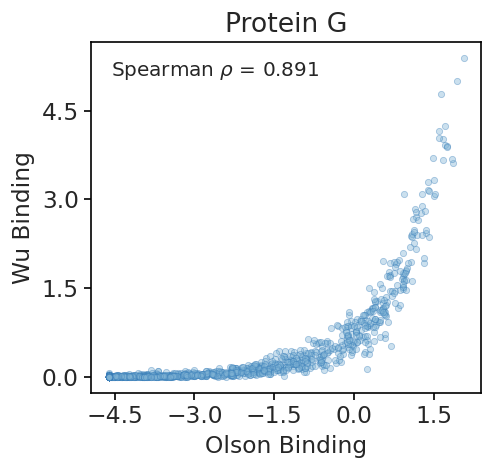

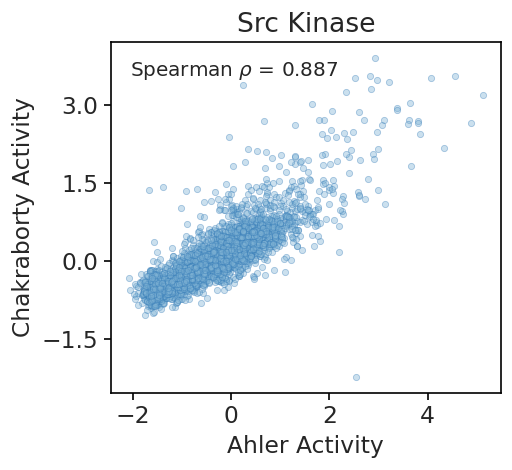

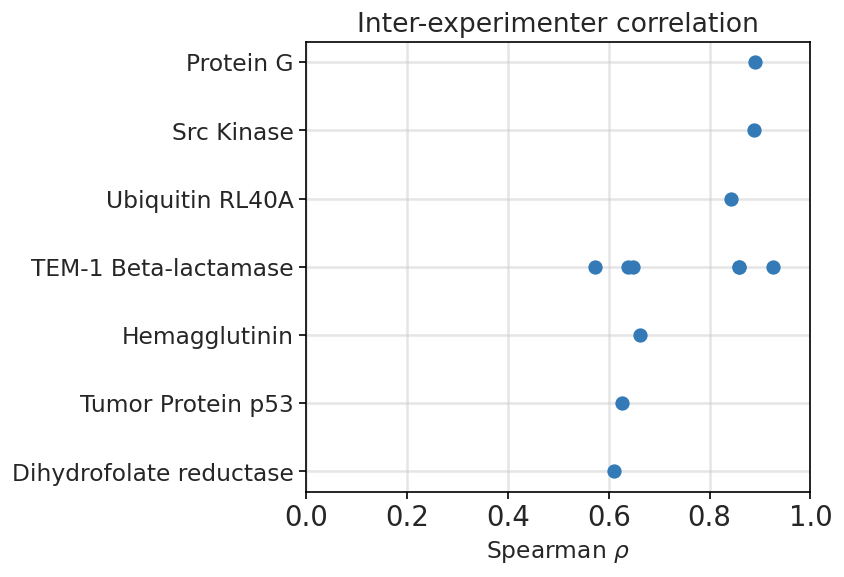

In [42]:
groups = pd.read_csv(repo_root / "data/proteingym_data/DMS_substitutions_groups.tsv", sep="\t")
csv_dir = repo_root / "data/proteingym_data/DMS_ProteinGym_substitutions"

groups["name"] = groups["name"].replace(name_replacements)

def merge_group_experiments(group_str: str, label_builder) -> tuple[pd.DataFrame, list[str]]:
    merged = None
    names = []
    for exp in group_str.split(","):
        file_name = exp.split(":")[0]
        readout = label_builder(exp)
        names.append(readout)
        tmp = pd.read_csv(csv_dir / file_name)[["mutant", "DMS_score"]].copy()
        tmp.columns = ["mutant", readout]
        merged = tmp if merged is None else merged.merge(tmp, on="mutant", how="inner")
    return merged, names

def pairwise_stats(merged: pd.DataFrame, names: list[str]) -> pd.DataFrame:
    stats = []
    for a, b in combinations(names, 2):
        pair_df = pd.DataFrame({"x": merged[a], "y": merged[b]})
        pair_df = pair_df.replace([np.inf, -np.inf], np.nan).dropna()
        if pair_df.shape[0] < 2:
            continue
        xx = pair_df["x"].to_numpy()
        yy = pair_df["y"].to_numpy()
        m, c = np.polyfit(xx, yy, 1)
        yhat = m * xx + c
        stats.append([a, b, r2_score(yy, yhat), spearmanr(xx, yy).correlation])
    return pd.DataFrame(stats, columns=["a", "b", "pearson", "spearman_rho"])

def plot_worst_pair(
    row: pd.Series,
    merged: pd.DataFrame,
    pair_stats_df: pd.DataFrame,
    color: str,
    line_color: str,
    output_path: Path,
    label_formatter=None,
    title_fontsize: int = 16,
    axis_fontsize: int = 14,
) -> None:
    worst = pair_stats_df.loc[pair_stats_df["pearson"].idxmin()]
    x_name = worst["a"]
    y_name = worst["b"]
    x_label = label_formatter(x_name) if label_formatter is not None else x_name
    y_label = label_formatter(y_name) if label_formatter is not None else y_name

    # Create figure and explicitly define the axes box [left, bottom, width, height]
    # This guarantees identical scatterplot dimensions across all generated images
    fig = plt.figure(figsize=(5.0, 4.5))
    ax = fig.add_axes([0.25, 0.20, 0.65, 0.65])
    
    ax.scatter(merged[x_name], merged[y_name], s=14, c=color, alpha=0.4, edgecolors=line_color, linewidths=0.5)
    ax.set_title(str(row["name"]), fontsize=title_fontsize)
    ax.set_xlabel(x_label, fontsize=axis_fontsize)
    ax.set_ylabel(y_label, fontsize=axis_fontsize)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    
    # Ensure ticks are present and black
    ax.tick_params(
        axis="both", 
        labelsize=axis_fontsize, 
        color="black", 
        length=4, 
        width=1, 
        bottom=True, 
        left=True
    )
    ax.grid(False)
    
    ax.text(
        0.05,
        0.95,
        f"Spearman $\\rho$ = {worst['spearman_rho']:.3f}",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=12,
    )
    
    # Make outlines smaller (1.0) and black
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.0)

    finalize_figure(fig, output_path)

def plot_group_summary(
    stats_df: pd.DataFrame,
    color: str,
    title: str,
    output_path: Path,
    highlight_binary: bool = False,
    figsize: tuple[float, float] = (5.5, 5.0),
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    # Lock the margins instead of using tight_layout to prevent squishing
    fig.subplots_adjust(left=0.35, right=0.95, top=0.90, bottom=0.15)
    
    ypos = np.arange(len(stats_df))
    ax.set_yticks(ypos)
    ax.set_yticklabels(stats_df["name"], fontsize=14)

    for i, values in enumerate(stats_df["all_spearman"]):
        if highlight_binary and stats_df["UniProt_ID"].iloc[i] == "KCNE1_HUMAN":
            ax.scatter(values, np.full(len(values), ypos[i]), facecolors="none", edgecolors=color, s=50, linewidths=2.5)
        else:
            ax.scatter(values, np.full(len(values), ypos[i]), color=color, s=50)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Spearman $\\rho$", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(alpha=0.5)

    # Ensure ticks are present and black
    ax.tick_params(
        axis="both", 
        color="black", 
        length=4, 
        width=1, 
        bottom=True, 
        left=True
    )

    # Make outlines smaller (1.0) and black
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.0)

    finalize_figure(fig, output_path)

def run_group_analysis(
    member_col: str,
    group_str_col: str,
    point_color: str,
    outline_color: str,
    out_subdir: str,
    summary_title: str,
    summary_filename: str,
    label_builder,
    label_formatter=None,
    highlight_binary: bool = False,
    summary_figsize: tuple[float, float] = (5.5, 5.0),
) -> None:
    out_dir = figure_dir(f"figure2/{out_subdir}")
    group_df = groups[groups[member_col] == 1].copy()
    group_df["group_str"] = group_df[group_str_col]
    all_stats = []

    for _, row in group_df.iterrows():
        if not isinstance(row["group_str"], str) or row["group_str"] == "":
            continue

        merged, names = merge_group_experiments(row["group_str"], label_builder)
        pair_stats_df = pairwise_stats(merged, names)
        if pair_stats_df.empty:
            continue

        plot_worst_pair(
            row=row,
            merged=merged,
            pair_stats_df=pair_stats_df,
            color=point_color,
            line_color=outline_color,
            output_path=out_dir / f"{row['UniProt_ID']}_spearmanrho.png",
            label_formatter=label_formatter,
        )
        all_stats.append(
            [
                row["UniProt_ID"], 
                pair_stats_df["spearman_rho"], 
                float(pair_stats_df["spearman_rho"].mean()),
                row["name"],
            ]
        )

    if not all_stats:
        print(f"No valid pairs found for {out_subdir}")
        return

    stats_df = pd.DataFrame(all_stats, columns=["UniProt_ID", "all_spearman", "mean_spearman", "name"]).sort_values("mean_spearman")
    plot_group_summary(
        stats_df=stats_df,
        color=outline_color,
        title=summary_title,
        output_path=out_dir / summary_filename,
        highlight_binary=highlight_binary,
        figsize=summary_figsize,
    )

def g1_label_builder(exp: str) -> str:
    return exp.split(":")[1]

def g2_label_builder(exp: str) -> str:
    info = exp.split(":")
    return f"{info[0].split('_')[2]}_{info[1]}"

def g2_label_formatter(label: str) -> str:
    left, right = label.split("_", maxsplit=1)
    # replace OrganismalFitness with "Organismal Fitness"
    if right == "OrganismalFitness":
        right = "Organismal Fitness"
    return f"{left} {right}"


# use seaborn
outline_1 = "#B39200"
color_1 = "#F2D06B"



run_group_analysis(
    member_col="group1_member",
    group_str_col="group1_str",
    point_color=color_1,
    outline_color=outline_1,
    out_subdir="interphenotype_g1",
    summary_title="Inter-phenotype correlation",
    summary_filename="interphenotype_group1_rho-scatterplot.png",
    label_builder=g1_label_builder,
    highlight_binary=False,
    summary_figsize=(7, 5),
)

# green color, tab20c index 9
outline_2 = "#337AB7"
color_2 = "#7FB3D5"

run_group_analysis(
    member_col="group2_member",
    group_str_col="group2_str",
    point_color=color_2,
    outline_color=outline_2,
    out_subdir="interexperimeter_g2",
    summary_title="Inter-experimenter correlation",
    summary_filename="interexperimenter_group2_rho-scatterplot.png",
    label_builder=g2_label_builder,
    label_formatter=g2_label_formatter,
    highlight_binary=False,
    summary_figsize=(7, 5),
)

## Figure 3
Load precomputed Figure 3 CSVs and plot inter-experimenter and inter-phenotype summaries.

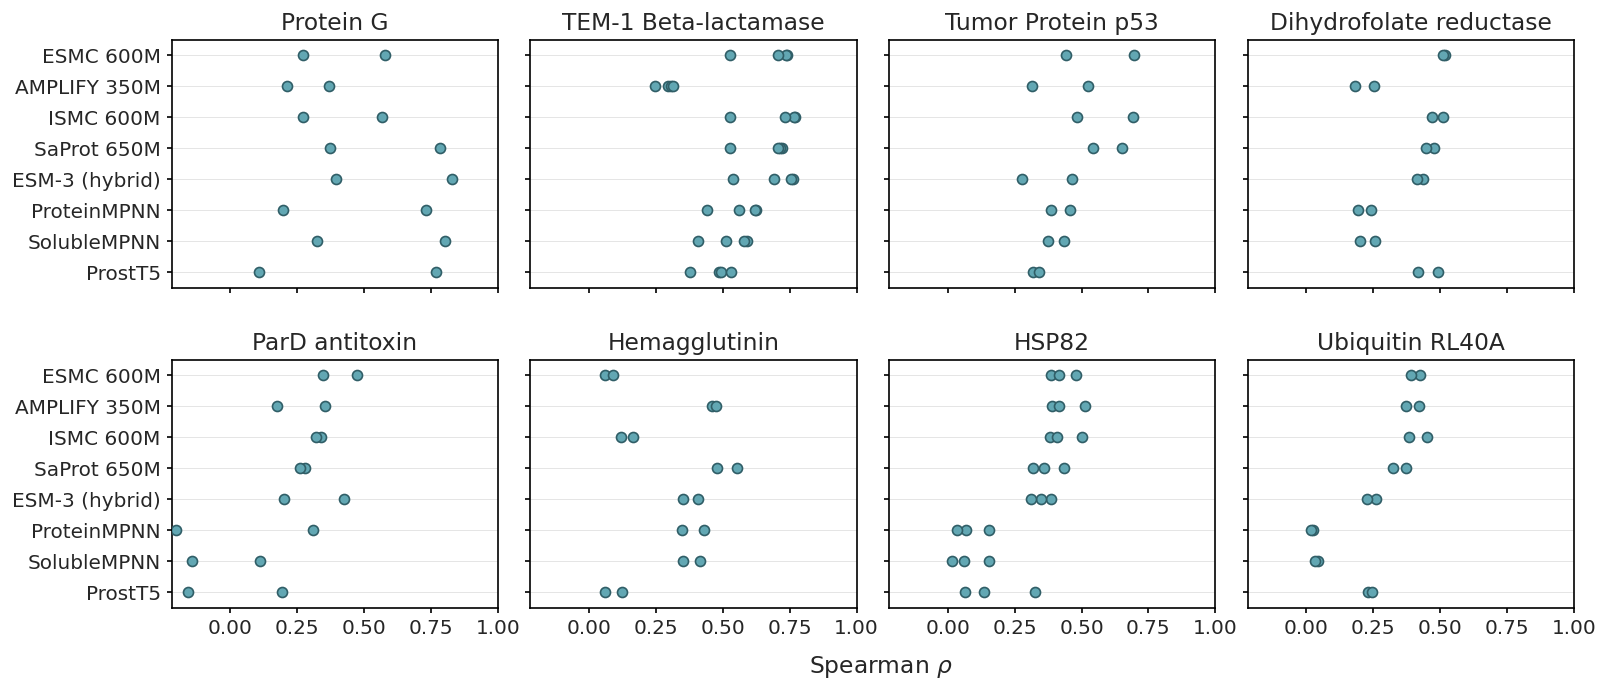

In [41]:
# read in data
interexperimenter = pd.read_csv(repo_root / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv")

# Melt to long format
df_long = interexperimenter.melt(id_vars="UniProt_ID", var_name="Model", value_name="rho")

# replace model names with more readable versions
df_long["Model"] = df_long["Model"].str.replace("ESM3_sm_both", "ESM-3 (hybrid)")
df_long["Model"] = df_long["Model"].str.replace("_", " ")

# Map IDs to names using the groups dataframe
name_mapping = dict(zip(groups["UniProt_ID"], groups["name"]))
df_long["name"] = df_long["UniProt_ID"].map(name_mapping)

# Setup the FacetGrid - using 'name' for the columns
g = sns.FacetGrid(
    df_long, 
    col="name", 
    col_wrap=4, 
    sharex=True, 
    height=3, 
    aspect=1.2
)

# Use stripplot
g.map_dataframe(
    sns.stripplot, 
    x="rho", 
    y="Model", 
    color="#62A7B3", 
    edgecolor="#305E67", 
    linewidth=1,
    alpha=1, 
    size=6, 
    jitter=False
)

# Styling (1pt black borders, small ticks)
for ax in g.axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    # Enable ticks but remove the individual facet x-labels
    ax.tick_params(axis="both", length=3, width=1, color='black', labelsize=12, bottom=True, left=True)
    ax.set_xlabel("") # Suppress individual x-labels
    ax.set_ylabel("") # Suppress individual y-labels
    ax.set_xlim(-0.22, 1)

# 1. Tell Seaborn to just use the column name (no "name = " prefix)
g.set_titles(col_template="{col_name}")

# 2. Consolidate all axes styling into a single loop
for ax in g.axes.flatten():
    # Force the title size directly via Matplotlib
    ax.set_title(ax.get_title(), fontsize=14)
    
    # Styling (1pt black borders, small ticks)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)
    
    ax.tick_params(axis="both", length=3, width=1, color='black', labelsize=12, bottom=True, left=True)
    ax.set_xlabel("") 
    ax.set_ylabel("") 
    ax.set_xlim(-0.22, 1)

    # Gridlines
    ax.grid(False, axis='x')
    ax.grid(True, axis='y', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)

# Adjust layout to make room at the bottom for the global label
g.figure.subplots_adjust(bottom=0.12)

# Add one single global label for the entire figure
g.figure.text(
    0.58, 0.02, 
    "Spearman $\\rho$", 
    ha="center", 
    va="bottom", 
    fontsize=14
)

finalize_figure(g.figure, figure_dir("figure3") / "figure3_beeswarm_faceted.png")

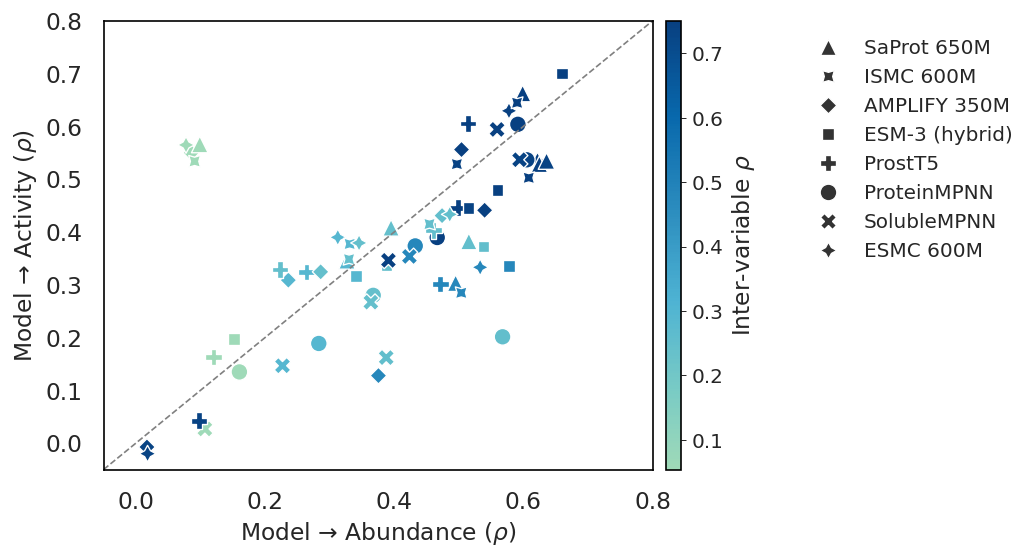

In [10]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

interphenotype = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix model names in the dataframe
interphenotype["model"] = interphenotype["model"].replace(label_replacements)
interphenotype["model"] = interphenotype["model"].str.replace("_", " ")

# 3. Define the desired legend order
# List the model names exactly as they appear after replacement
desired_order = [
    "SaProt 650M",
    "ISMC 600M",
    "AMPLIFY 350M",
    "ESM-3 (hybrid)",
    "ProstT5",
    "ProteinMPNN",
    "SolubleMPNN",
    "ESMC 600M",
]

# Create the truncated colormap
puor_base = plt.get_cmap("GnBu")
truncated_colors = puor_base(np.linspace(0.4, 1, 256))
custom_puor = mcolors.ListedColormap(truncated_colors)

fig, ax = plt.subplots(figsize=(9, 5))

# interphenotype = interphenotype[(interphenotype["proteinid"] == "KCNE1_HUMAN") | (interphenotype["proteinid"] == "SPIKE_SARS2")].copy()

sns.scatterplot(
    data=interphenotype,
    x="expression_rs",
    y="selection_rs",
    hue="variable_rs",
    style="model",
    palette=custom_puor,
    s=100,
    ax=ax,
    legend="brief",
)

# Extract and reorder the legend items
handles, labels = ax.get_legend_handles_labels()
try:
    model_idx = labels.index("model")
    raw_handles = handles[model_idx + 1:]
    raw_labels = labels[model_idx + 1:]
    
    # Map labels to handles for easy reordering
    handle_map = dict(zip(raw_labels, raw_handles))
    
    # Filter desired_order to only include models actually present in the data
    ordered_labels = [m for m in desired_order if m in handle_map]
    ordered_handles = [handle_map[m] for m in ordered_labels]
    
except (ValueError, KeyError):
    # Fallback if "model" key isn't found in legend labels
    ordered_handles, ordered_labels = handles, labels

ax.legend(
    ordered_handles, 
    ordered_labels, 
    title=None, 
    bbox_to_anchor=(1.25, 1), 
    loc="upper left", 
    frameon=False,
    fontsize=12,
)

norm = mcolors.Normalize(vmin=interphenotype["variable_rs"].min(), vmax=interphenotype["variable_rs"].max())
sm = cm.ScalarMappable(cmap=custom_puor, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Inter-variable $\\rho$", fontsize=14)

ax.plot([-0.05, 1], [-0.05, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Model → Abundance ($\\rho$)", fontsize=14)
ax.set_ylabel("Model → Activity ($\\rho$)", fontsize=14)
ax.tick_params(labelsize=14)

cbar.ax.tick_params(labelsize=12, color="black", length=3, width=0.5)

ax.set_xlim(-0.05, 0.8)
ax.set_ylim(-0.05, 0.8)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

ax.grid(False)
fig.tight_layout()

finalize_figure(fig, figure_dir("figure3") / "figure3_interphenotype.png")

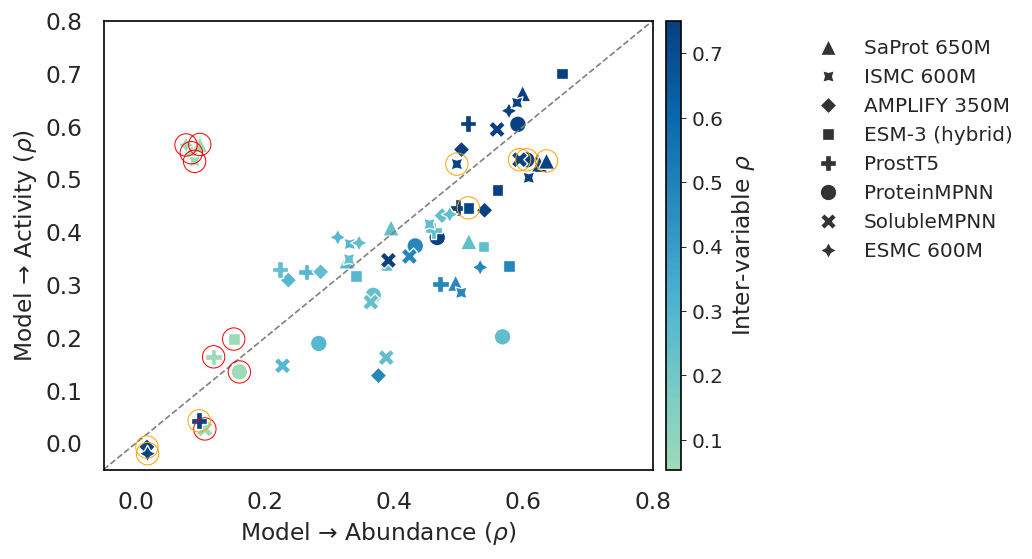

In [11]:
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

interphenotype = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix model names in the dataframe
interphenotype["model"] = interphenotype["model"].replace(label_replacements)
interphenotype["model"] = interphenotype["model"].str.replace("_", " ")

# 3. Define the desired legend order
desired_order = [
    "SaProt 650M",
    "ISMC 600M",
    "AMPLIFY 350M",
    "ESM-3 (hybrid)",
    "ProstT5",
    "ProteinMPNN",
    "SolubleMPNN",
    "ESMC 600M",
]

# Create the truncated colormap
puor_base = plt.get_cmap("GnBu")
truncated_colors = puor_base(np.linspace(0.4, 1, 256))
custom_puor = mcolors.ListedColormap(truncated_colors)

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=interphenotype,
    x="expression_rs",
    y="selection_rs",
    hue="variable_rs",
    style="model",
    palette=custom_puor,
    s=100,
    ax=ax,
    legend="brief",
)

# --- NEW: Outline specific proteins ---
# Tunable colors for the specific protein IDs
highlight_settings = {
    "KCNE1_HUMAN": "red",
    "SPIKE_SARS2": "orange"
}

for protein_id, color in highlight_settings.items():
    subset = interphenotype[interphenotype["proteinid"] == protein_id]
    ax.scatter(
        subset["expression_rs"],
        subset["selection_rs"],
        facecolors="none",      # Keep the inside empty so the original point shows
        edgecolors=color,       # Apply the tunable color
        linewidths=0.6,           # Thickness of the outline
        s=180,                  # Slightly larger than the original s=100 to frame it
        zorder=5                # Ensure the outline is drawn on top of other points
    )
# --------------------------------------

# Extract and reorder the legend items
handles, labels = ax.get_legend_handles_labels()
try:
    model_idx = labels.index("model")
    raw_handles = handles[model_idx + 1:]
    raw_labels = labels[model_idx + 1:]
    
    # Map labels to handles for easy reordering
    handle_map = dict(zip(raw_labels, raw_handles))
    
    # Filter desired_order to only include models actually present in the data
    ordered_labels = [m for m in desired_order if m in handle_map]
    ordered_handles = [handle_map[m] for m in ordered_labels]
    
except (ValueError, KeyError):
    # Fallback if "model" key isn't found in legend labels
    ordered_handles, ordered_labels = handles, labels

ax.legend(
    ordered_handles, 
    ordered_labels, 
    title=None, 
    bbox_to_anchor=(1.25, 1), 
    loc="upper left", 
    frameon=False,
    fontsize=12,
)

norm = mcolors.Normalize(vmin=interphenotype["variable_rs"].min(), vmax=interphenotype["variable_rs"].max())
sm = cm.ScalarMappable(cmap=custom_puor, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Inter-variable $\\rho$", fontsize=14)

ax.plot([-0.05, 1], [-0.05, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Model → Abundance ($\\rho$)", fontsize=14)
ax.set_ylabel("Model → Activity ($\\rho$)", fontsize=14)
ax.tick_params(labelsize=14)

cbar.ax.tick_params(labelsize=12, color="black", length=3, width=0.5)

ax.set_xlim(-0.05, 0.8)
ax.set_ylim(-0.05, 0.8)

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

ax.grid(False)
fig.tight_layout()

finalize_figure(fig, figure_dir("figure3") / "figure3_interphenotype_2proteins.png")

### Figure 3C: Cross-context model summary heatmap
This panel summarizes each model across inter-experimenter and inter-phenotype settings to make rank patterns easier to compare at a glance.

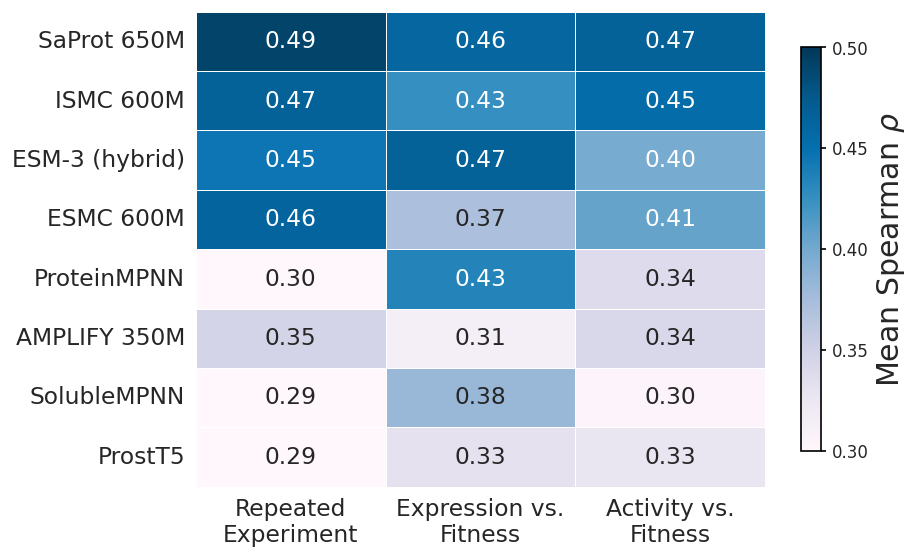

In [11]:
# Build a compact cross-context model summary for Figure 3.
interexperimenter_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv")
interphenotype_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix interexperimenter_df (where models are columns)
# Rename columns first, then replace underscores in the remaining headers
interexperimenter_df = interexperimenter_df.rename(columns=label_replacements)
interexperimenter_df.columns = [c.replace("_", " ") if c != "UniProt_ID" else c for c in interexperimenter_df.columns]

# 3. Fix interphenotype_df (where models are values in a column)
interphenotype_df["model"] = interphenotype_df["model"].replace(label_replacements)
interphenotype_df["model"] = interphenotype_df["model"].str.replace("_", " ")

# --- Rest of the processing remains the same ---

interexp_long = interexperimenter_df.melt(
    id_vars="UniProt_ID", var_name="model", value_name="rho"
).dropna(subset=["rho"])

interexp_summary = (
    interexp_long.groupby("model", as_index=False)["rho"]
    .mean()
    .rename(columns={"rho": "inter_experimenter"})
)

interpheno_summary = (
    interphenotype_df.groupby("model", as_index=False)[["expression_rs", "selection_rs"]]
    .mean()
    .rename(
        columns={
            "expression_rs": "inter_phenotype_expression",
            "selection_rs": "inter_phenotype_selection",
        }
    )
)

summary_df = interexp_summary.merge(interpheno_summary, on="model", how="inner")
if summary_df.empty:
    raise ValueError("No overlapping models found between Figure 3 datasets.")

summary_df["overall_mean"] = summary_df[
    ["inter_experimenter", "inter_phenotype_expression", "inter_phenotype_selection"]
].mean(axis=1)
summary_df = summary_df.sort_values("overall_mean", ascending=False).reset_index(drop=True)

heatmap_df = summary_df.set_index("model")[[
    "inter_experimenter",
    "inter_phenotype_expression",
    "inter_phenotype_selection",
]]

fig, ax = plt.subplots(figsize=(8.0, 5))
sns.heatmap(
    heatmap_df,
    cmap="PuBu",
    vmin=0.3,
    vmax=0.5,
    annot=True,
    annot_kws={"size": 14},
    fmt=".2f",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Mean Spearman $\\rho$", "shrink": 0.85, "ticks": [0.3, 0.35, 0.4, 0.45, 0.5]},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([
    "Repeated\nExperiment",
    "Expression vs.\nFitness",
    "Activity vs.\nFitness",
], rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=14)

# Apply standard 1pt black border and tick styling
ax.tick_params(axis="both", color="black", length=3, width=1)
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, color="black", length=3, width=1)
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

fig.tight_layout()
finalize_figure(fig, figure_dir("figure3") / "figure3_cross_context_model_summary_heatmap.png")

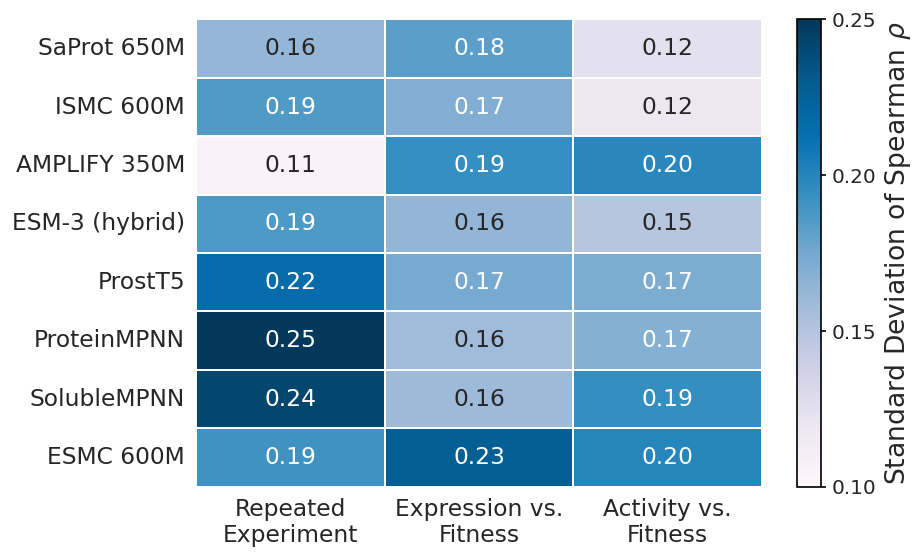

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Build a compact cross-context model standard deviation summary for Figure 3.
interexperimenter_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv")
interphenotype_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix interexperimenter_df (where models are columns)
interexperimenter_df = interexperimenter_df.rename(columns=label_replacements)
interexperimenter_df.columns = [c.replace("_", " ") if c != "UniProt_ID" else c for c in interexperimenter_df.columns]

# 3. Fix interphenotype_df (where models are values in a column)
interphenotype_df["model"] = interphenotype_df["model"].replace(label_replacements)
interphenotype_df["model"] = interphenotype_df["model"].str.replace("_", " ")

# --- Standard Deviation Processing ---

interexp_long = interexperimenter_df.melt(
    id_vars="UniProt_ID", var_name="model", value_name="rho"
).dropna(subset=["rho"])

interexp_summary = (
    interexp_long.groupby("model", as_index=False)["rho"]
    .std()
    .rename(columns={"rho": "inter_experimenter_std"})
)

interpheno_summary = (
    interphenotype_df.groupby("model", as_index=False)[["expression_rs", "selection_rs"]]
    .std()
    .rename(
        columns={
            "expression_rs": "inter_phenotype_expression_std",
            "selection_rs": "inter_phenotype_selection_std",
        }
    )
)

summary_df = interexp_summary.merge(interpheno_summary, on="model", how="inner")
if summary_df.empty:
    raise ValueError("No overlapping models found between Figure 3 datasets.")

# Calculate overall standard deviation and sort ascending (smallest on top)
summary_df["overall_std"] = summary_df[
    ["inter_experimenter_std", "inter_phenotype_expression_std", "inter_phenotype_selection_std"]
].mean(axis=1)

summary_df = summary_df.sort_values("overall_std", ascending=True).reset_index(drop=True)

heatmap_df = summary_df.set_index("model")[[
    "inter_experimenter_std",
    "inter_phenotype_expression_std",
    "inter_phenotype_selection_std",
]]

# # truncate the colormap RdBu_R to make it less red
# # remake the cmap from RdBu_r with a narrower range to avoid extreme reds
# rdbu_base = plt.get_cmap("RdBu_r")
# truncated_colors = rdbu_base(np.linspace(0.25, 0.8, 256))
# custom_rdbu = mcolors.ListedColormap(truncated_colors)

# # make a custom viridis with less chroma
# viridis_base = plt.get_cmap("viridis")
# truncated_colors = viridis_base(np.linspace(0.1, 0.9, 256))
# custom_viridis = mcolors.ListedColormap(truncated_colors)
# # add in some white to the color:
# custom_viridis.set_under("white")


fig, ax = plt.subplots(figsize=(8.0, 5))
sns.heatmap(
    heatmap_df,
    cmap="PuBu",
    vmin=0.1,
    vmax=0.25,
    annot=True,
    annot_kws={"size": 14},
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Standard Deviation of Spearman $\\rho$", "shrink": 1, "ticks": [0, 0.05, 0.10, 0.15, 0.20, 0.25]},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([
    "Repeated\nExperiment",
    "Expression vs.\nFitness",
    "Activity vs.\nFitness",
], rotation=0, fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

# Apply standard 1pt black border and tick styling to main axes
ax.tick_params(axis="both", color="black", length=3, width=1)

# Apply standard styling to the colorbar
# Grab the colorbar and set the label with your desired fontsize
cbar = ax.collections[0].colorbar

# cbar.ax.invert_yaxis()
cbar.set_label("Standard Deviation of Spearman $\\rho$", fontsize=16)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12, color="black", length=3, width=1)
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

fig.tight_layout()
finalize_figure(fig, figure_dir("figure3") / "figure3_cross_context_model_std_heatmap.png")

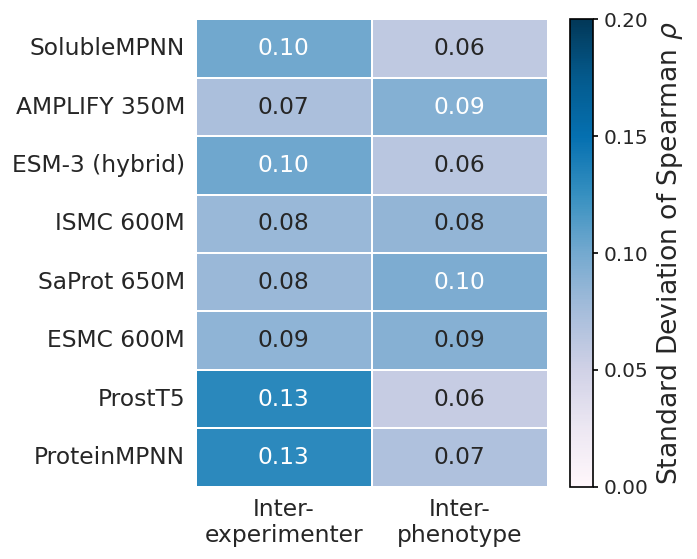

In [177]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Build a compact cross-context model standard deviation summary for Figure 3.
interexperimenter_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv")
interphenotype_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix interexperimenter_df (where models are columns)
interexperimenter_df = interexperimenter_df.rename(columns=label_replacements)
interexperimenter_df.columns = [c.replace("_", " ") if c != "UniProt_ID" else c for c in interexperimenter_df.columns]

# 3. Fix interphenotype_df (where models are values in a column)
interphenotype_df["model"] = interphenotype_df["model"].replace(label_replacements)
interphenotype_df["model"] = interphenotype_df["model"].str.replace("_", " ")


# --- Standard Deviation Processing ---

# --- Inter-experimenter ---
interexp_long = interexperimenter_df.melt(
    id_vars="UniProt_ID", var_name="model", value_name="rho"
).dropna(subset=["rho"])

# Step 1: Calculate standard deviation for EACH protein across the different labs/experiments
interexp_protein_std = (
    interexp_long.groupby(["model", "UniProt_ID"], as_index=False)["rho"]
    .std()
)

# Step 2: Average those standard deviations across all 8 proteins
interexp_summary = (
    interexp_protein_std.groupby("model", as_index=False)["rho"]
    .mean()
    .rename(columns={"rho": "inter_experimenter_std"})
)


# --- Inter-phenotype ---
# Step 1: Calculate standard deviation BETWEEN the two measurements for each protein row
interphenotype_df["inter_phenotype_std"] = interphenotype_df[["expression_rs", "selection_rs"]].std(axis=1)

# Step 2: Average those standard deviations across all proteins for each model
interpheno_summary = (
    interphenotype_df.groupby("model", as_index=False)["inter_phenotype_std"]
    .mean()
)

summary_df = interexp_summary.merge(interpheno_summary, on="model", how="inner")
if summary_df.empty:
    raise ValueError("No overlapping models found between Figure 3 datasets.")

# Calculate overall standard deviation and sort ascending (smallest on top)
summary_df["overall_std"] = summary_df[["inter_experimenter_std", "inter_phenotype_std"]].mean(axis=1)
summary_df = summary_df.sort_values("overall_std", ascending=True).reset_index(drop=True)

# Select the two columns for the heatmap
heatmap_df = summary_df.set_index("model")[["inter_experimenter_std", "inter_phenotype_std"]]

fig, ax = plt.subplots(figsize=(6.0, 5)) # slightly narrower since we dropped a column
sns.heatmap(
    heatmap_df,
    cmap="PuBu",
    vmin=0,
    vmax=0.2,
    annot=True,
    annot_kws={"size": 14},
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Standard Deviation of Spearman $\\rho$", "shrink": 1, "ticks": [0, 0.05, 0.10, 0.15, 0.20, 0.25]},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")

# Update labels for the two columns
ax.set_xticklabels([
    "Inter-\nexperimenter",
    "Inter-\nphenotype",
], rotation=0, fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

# Apply standard 1pt black border and tick styling to main axes
ax.tick_params(axis="both", color="black", length=3, width=1)

# Apply standard styling to the colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Standard Deviation of Spearman $\\rho$", fontsize=16)
cbar.ax.tick_params(labelsize=12, color="black", length=3, width=1)
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

fig.tight_layout()
finalize_figure(fig, figure_dir("figure3") / "figure3_cross_context_model_std_heatmap.png")

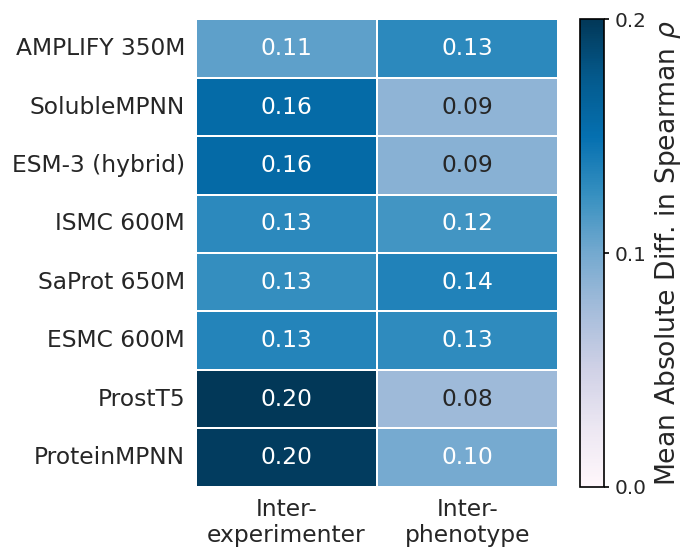

In [179]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Build a compact cross-context model standard deviation summary for Figure 3.
interexperimenter_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv")
interphenotype_df = pd.read_csv(repo_root / "outputs/csvs/figure3_interphenotype_g1.csv")

# 1. Define specific paper-ready replacements
label_replacements = {
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ESM2": "ESM-2",
}

# 2. Fix interexperimenter_df (where models are columns)
interexperimenter_df = interexperimenter_df.rename(columns=label_replacements)
interexperimenter_df.columns = [c.replace("_", " ") if c != "UniProt_ID" else c for c in interexperimenter_df.columns]

# 3. Fix interphenotype_df (where models are values in a column)
interphenotype_df["model"] = interphenotype_df["model"].replace(label_replacements)
interphenotype_df["model"] = interphenotype_df["model"].str.replace("_", " ")


# --- Absolute Difference Processing ---

# --- Inter-experimenter ---
interexp_long = interexperimenter_df.melt(
    id_vars="UniProt_ID", var_name="model", value_name="rho"
).dropna(subset=["rho"])

# Step 1: Calculate the absolute difference (max - min) for EACH protein across labs/experiments
interexp_protein_diff = (
    interexp_long.groupby(["model", "UniProt_ID"], as_index=False)["rho"]
    .agg(lambda x: x.max() - x.min()) # Exact absolute diff for 2 values, full range for >2
)

# Step 2: Average those differences across all 8 proteins
interexp_summary = (
    interexp_protein_diff.groupby("model", as_index=False)["rho"]
    .mean()
    .rename(columns={"rho": "inter_experimenter_diff"})
)


# --- Inter-phenotype ---
# Step 1: Calculate absolute difference BETWEEN the two measurements for each protein row
interphenotype_df["inter_phenotype_diff"] = (interphenotype_df["expression_rs"] - interphenotype_df["selection_rs"]).abs()

# Step 2: Average those differences across all proteins for each model
interpheno_summary = (
    interphenotype_df.groupby("model", as_index=False)["inter_phenotype_diff"]
    .mean()
)

summary_df = interexp_summary.merge(interpheno_summary, on="model", how="inner")
if summary_df.empty:
    raise ValueError("No overlapping models found between Figure 3 datasets.")

# Calculate overall mean difference and sort ascending (smallest on top)
summary_df["overall_diff"] = summary_df[["inter_experimenter_diff", "inter_phenotype_diff"]].mean(axis=1)
summary_df = summary_df.sort_values("overall_diff", ascending=True).reset_index(drop=True)

# Select the two columns for the heatmap
heatmap_df = summary_df.set_index("model")[["inter_experimenter_diff", "inter_phenotype_diff"]]

fig, ax = plt.subplots(figsize=(6.0, 5))
sns.heatmap(
    heatmap_df,
    cmap="PuBu",
    vmin=0,
    vmax=0.2, # Increased vmax to account for larger numbers
    annot=True,
    annot_kws={"size": 14},
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Mean Absolute Difference in $\\rho$", "shrink": 1, "ticks": [0, 0.1, 0.2, 0.3, 0.4]},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")

# Update labels for the two columns
ax.set_xticklabels([
    "Inter-\nexperimenter",
    "Inter-\nphenotype",
], rotation=0, fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

# Apply standard 1pt black border and tick styling to main axes
ax.tick_params(axis="both", color="black", length=3, width=1)

# Apply standard styling to the colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Mean Absolute Diff. in Spearman $\\rho$", fontsize=16)
cbar.ax.tick_params(labelsize=12, color="black", length=3, width=1)
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(1.0)

fig.tight_layout()
finalize_figure(fig, figure_dir("figure3") / "figure3_cross_context_model_std_heatmap.png")

## Figure 4
Load logits + experiment CSV for scatter, and precomputed density CSV for KDE overlays.

In [37]:
# read in pickle file of logits and print all protein ids
logits_dict = pd.read_pickle(repo_root / "outputs/logits/proteingym/ESM3_sm_open_v0.both.logits.x.combined.pkl")
print("Protein IDs in logits file:")
for key in logits_dict.keys():
    print(key)
    

Protein IDs in logits file:
HSP82_YEAST.ESM3_sm_open_v0.both.logits.indices_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21_22_23_24_25_26_27_28_29_30_31_32_33_34_35_36_37_38_39_40_41_42_43_44_45_46_47_48_49_50_51_52_53_54_55_56_57_58_59_60_61_62_63_64_65_66_67_68_69_70_71_72_73_74_75_76_77_78_79_80_81_82_83_84_85_86_87_88_89_90_91_92_93_94_95_96_97_98_99_100_101_102_103_104_105_106_107_108_109_110_111_112_113_114_115_116_117_118_119_120_121_122_123_124_125_126_127_128_129_130_131_132_133_134_135_136_137_138_139_140_141_142_143_144_145_146_147_148_149_150_151_152_153_154_155_156_157_158_159_160_161_162_163_164_165_166_167_168_169_170_171_172_173_174_175_176_177_178_179_180_181_182_183_184_185_186_187_188_189_190_191_192_193_194_195_196_197_198_199_200_201_202_203_204_205_206_207_208_209_210_211_212_213_214_215_216_217_218_219_220_221_223_224_225_226_227_228_229_230_231_232_233_234_235_236_237_238_239_240_241_242_243_244_245_246_247_248_249_250_251_252_253_254_255_256_257_258_259_26

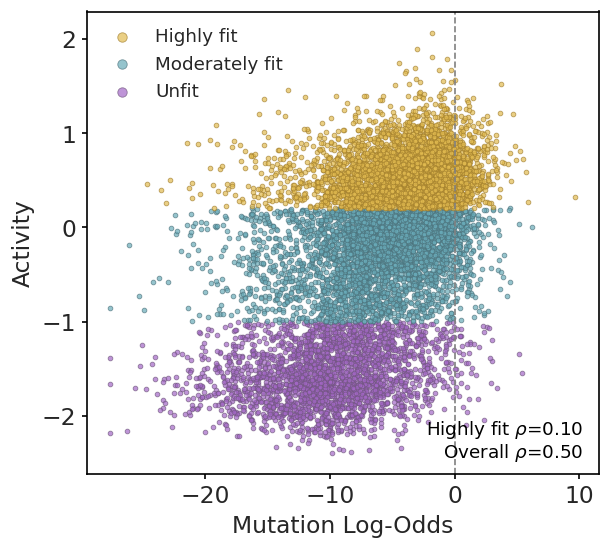

Model: ESM3_sm_both


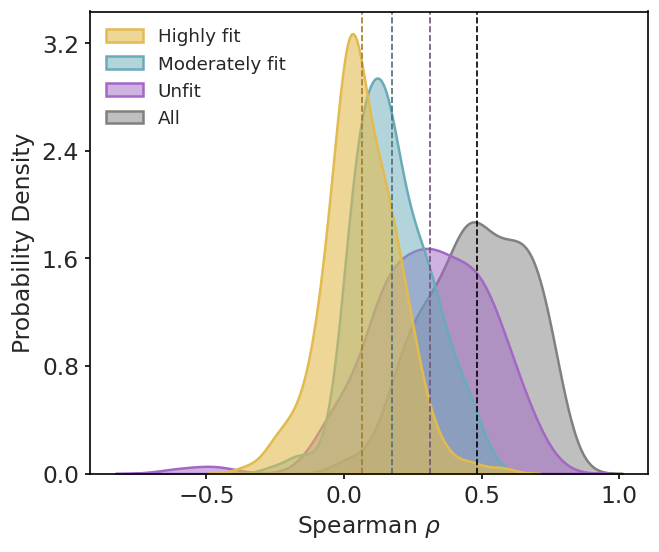

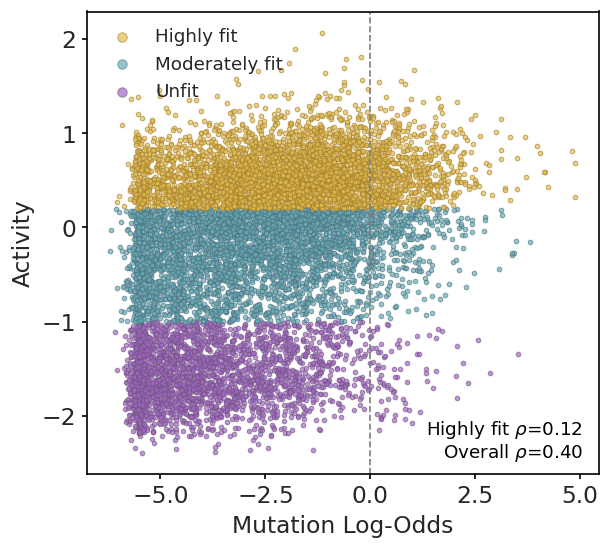

Model: ProteinMPNN


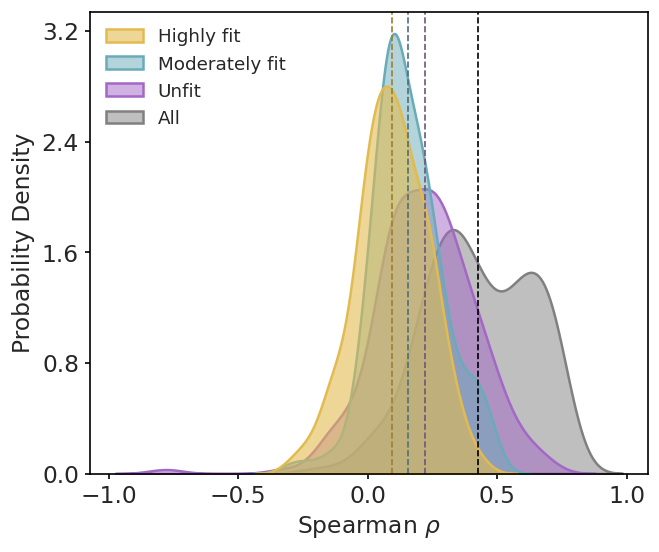

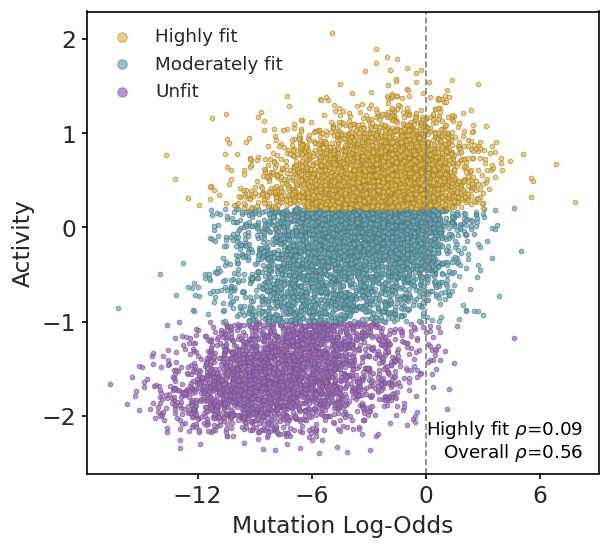

Model: ESMC-600M


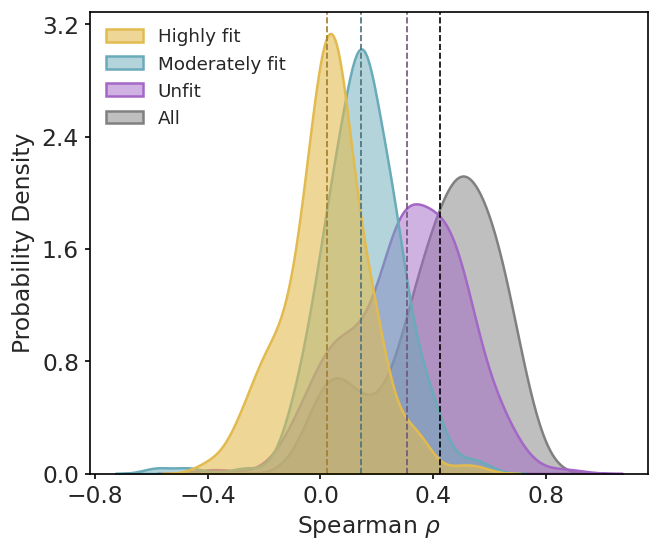

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
from pathlib import Path
from scipy.stats import spearmanr

# --- DATA LOADING (remains same) ---
models = ['ESM3_sm_both', 'ProteinMPNN', 'ESMC-600M']
pkls = ['ESM3_sm_open_v0.both.logits.x.combined.pkl',
        'protein_mpnn.proteinmpnn_v_48_020.logits.x.combined.use_sequence0.pkl',
        'esmc_600m.logits.x.combined.pkl']

for model, pkl in zip(models, pkls):

    logits_path = repo_root / f"outputs/logits/proteingym/{pkl}"
    density_path = repo_root / f"outputs/csvs/figure4_fitclass_density_{model}.csv"


    exp_path = repo_root / "data/proteingym_data/DMS_ProteinGym_substitutions/S22A1_HUMAN_Yee_2023_activity.csv"

    with open(logits_path, "rb") as f:
        all_logits = pickle.load(f)

    protein_id = "S22A1_HUMAN"
    matching_keys = [k for k in all_logits.keys() if protein_id in k]
    if len(matching_keys) == 0:
        raise ValueError(f"No matching logits key found for {protein_id}. Check the keys in the logits file.")
    preds_name = matching_keys[0]
    preds = all_logits[preds_name]

    index_list = [int(x) for x in preds_name.split("indices_")[-1].split("_")]
    amino_acids = ["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]
    scaled = preds - np.max(preds, axis=1, keepdims=True)
    exp_preds = np.exp(scaled)
    probs = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)

    probs_df = pd.DataFrame(probs, index=index_list, columns=amino_acids).stack().reset_index()
    probs_df.columns = ["index", "amino_acid", "prob"]

    exp_df = pd.read_csv(exp_path)
    parsed = exp_df["mutant"].str.extract(r"([A-Za-z])(\d+)([A-Za-z])")
    exp_df["wt"] = parsed[0]
    exp_df["index"] = pd.to_numeric(parsed[1], errors="coerce")
    exp_df["mut"] = parsed[2]
    exp_df = exp_df.dropna(subset=["wt", "index", "mut"]).copy()
    exp_df["index"] = exp_df["index"].astype(int)

    mut_df = exp_df.merge(probs_df, left_on=["index", "mut"], right_on=["index", "amino_acid"], how="inner")
    mut_df = mut_df.rename(columns={"prob": "mut_prob"})
    wt_df = exp_df.merge(probs_df, left_on=["index", "wt"], right_on=["index", "amino_acid"], how="inner")
    wt_df = wt_df[["mutant", "prob"]].rename(columns={"prob": "wt_prob"})

    plot_df = mut_df.merge(wt_df, on="mutant", how="inner")
    plot_df["log_odds"] = np.log(plot_df["mut_prob"].clip(1e-12)) - np.log(plot_df["wt_prob"].clip(1e-12))
    plot_df["exp"] = plot_df["DMS_score"]

    fit_subset = plot_df[plot_df["DMS_score_bin"] == 1]
    fit_min = fit_subset["exp"].min()
    fittest_min = fit_subset["exp"].median()

    colors = ["#744C8AFF", "#4C9DAFFF", "#E1C319FF"]  # Custom colors for unfit, fit, fittest
    edge_colors = ["#513361FF", "#377380FF", "#A48E12FF"]  # Matching edge colors for better visibility
    colors = ["#AC5858FF", "#DB9944FF", "#E1C319FF"]  # Custom colors for unfit, fit, fittest
    edge_colors = ["#883E3EFF", "#BB8837FF", "#BEA100FF"]  # Matching edge colors for better visibility
    colors = ["#A367C6FF", "#69ABB9FF", "#E2BB50FF"]  # Custom colors for unfit, fit, fittest
    edge_colors = ["#6E557BFF", "#4B7079FF", "#A07D2CFF"]  # Matching edge colors for better visibility

    # ==============================================================================
    # Plot 1: fitness_scatter.png
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(5.5, 5))

    # Define the three distinct, non-overlapping bands
    unfit_mask = plot_df["exp"] <= fit_min
    fit_mask = (plot_df["exp"] > fit_min) & (plot_df["exp"] <= fittest_min)
    fittest_mask = plot_df["exp"] > fittest_min

    # Plot each band individually
    ax.scatter(plot_df.loc[unfit_mask, "log_odds"], plot_df.loc[unfit_mask, "exp"], 
            s=8, label="unfit", color=colors[0], alpha=0.7,
            edgecolors=edge_colors[0], linewidth=0.5
            )

    ax.scatter(plot_df.loc[fit_mask, "log_odds"], plot_df.loc[fit_mask, "exp"], 
            s=8, label="fit", color=colors[1], alpha=0.7,
            edgecolors=edge_colors[1], linewidth=0.5
            )

    ax.scatter(plot_df.loc[fittest_mask, "log_odds"], plot_df.loc[fittest_mask, "exp"], 
            s=8, label="fittest", color=colors[2], alpha=0.7,
            edgecolors=edge_colors[2], linewidth=0.5
            )

    
    # calculate spearman for each band and print
    # unfit_spearman = spearmanr(plot_df.loc[unfit_mask, "log_odds"], plot_df.loc[unfit_mask, "exp"]).correlation
    # fit_spearman = spearmanr(plot_df.loc[fit_mask, "log_odds"], plot_df.loc[fit_mask, "exp"]).correlation
    # find the spearman for all points together
    fittest_spearman = spearmanr(plot_df.loc[fittest_mask, "log_odds"], plot_df.loc[fittest_mask, "exp"]).correlation
    overall_spearman = spearmanr(plot_df["log_odds"], plot_df["exp"]).correlation

    # place text on the plot with the spearman values
    # ax.text(0.85, 0.95, f"Unfit $\\rho$={unfit_spearman:.2f}", transform=ax.transAxes, fontsize=11, verticalalignment='top', color=edge_colors[0])
    # ax.text(0.85, 0.90, f"Moderately fit $\\rho$={fit_spearman:.2f}", transform=ax.transAxes, fontsize=11, verticalalignment='top', color=edge_colors[1])
    ax.text(0.97, 0.12, f"Highly fit $\\rho$={fittest_spearman:.2f}", transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right', color='black')
    ax.text(0.97, 0.07, f"Overall $\\rho$={overall_spearman:.2f}", transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='right', color='black')

    # change legend order to match the plotting order
    handles, labels = ax.get_legend_handles_labels()
    order = [2, 1, 0]  # unfit, fit, fittest
    ax.legend([handles[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0.71, 0.27), loc="upper left", fontsize=11, markerscale=2, frameon=False)

    # make legend names Highly fit, Moderately fit, Unfit
    new_labels = ["Highly fit", "Moderately fit", "Unfit"]
    ax.legend([handles[i] for i in order], new_labels, bbox_to_anchor=(0, 1), loc="upper left", fontsize=11, markerscale=2, frameon=False)

    # Change: set linewidth to 1pt for dashed line
    ax.axvline(0, c="grey", linestyle="--", linewidth=1)

    ax.set_xlabel("Mutation Log-Odds", fontsize=14)
    ax.set_ylabel("Activity", fontsize=14)

    # Change: Explicitly set ticks, small size, 1pt width, color black
    ax.tick_params(
        axis="both",
        which='major',
        labelsize=14,
        direction='out',
        length=3,  # small
        width=1,   # standard 1pt
        color='black',
        bottom=True,
        left=True
    )

    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    # remove gridlines
    ax.grid(False)

    # Change: Ensure border is black and 1pt
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    finalize_figure(fig, figure_dir("figure4") / f"fitness_scatter_{model}.png")


    # ==============================================================================
    # Plot 2: fitness_density.png
    # ==============================================================================
    density_df = pd.read_csv(density_path)

    fig, ax = plt.subplots(figsize=(6, 5))

    sns.kdeplot(density_df["all_rho"], label="All", fill=True, alpha=0.5, color="grey", ax=ax)
    sns.kdeplot(density_df["unfit_rho"], label="Unfit", fill=True, alpha=0.5, color=colors[0], ax=ax)
    sns.kdeplot(density_df["fit_rho"], label="Moderately fit", fill=True, alpha=0.5, color=colors[1], ax=ax)
    sns.kdeplot(density_df["fittest_rho"], label="Highly fit", fill=True, alpha=0.6, color=colors[2], ax=ax)

    # Change: set linewidth to 1pt for mean lines
    ax.axvline(density_df["all_rho"].mean(), color="k", linestyle="--", linewidth=1)
    ax.axvline(density_df["unfit_rho"].mean(), color=edge_colors[0], linestyle="--", linewidth=1)
    ax.axvline(density_df["fit_rho"].mean(), color=edge_colors[1], linestyle="--", linewidth=1)
    ax.axvline(density_df["fittest_rho"].mean(), color=edge_colors[2], linestyle="--", linewidth=1)

    ax.set_xlabel("Spearman $\\rho$", fontsize=14)
    ax.set_ylabel("Probability Density", fontsize=14)

    # Change: Explicitly set ticks, small size, 1pt width, color black
    ax.tick_params(
        axis="both",
        which='major',
        labelsize=14,
        direction='out',
        length=3,  # small
        width=1,   # standard 1pt
        color='black',
        bottom=True,
        left=True
    )

    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    # remove gridlines
    ax.grid(False)    

    # Change: Ensure border is black and 1pt
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    # ax.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=11, frameon=False)
    # reorder legend
    handles, labels = ax.get_legend_handles_labels()
    order = [3, 2, 1, 0]  # all, unfit, fit, fittest
    ax.legend([handles[i] for i in order], [labels[i] for i in order], bbox_to_anchor=(0, 1), loc="upper left", fontsize=11, frameon=False)

    print(f"Model: {model}")
    finalize_figure(fig, figure_dir("figure4") / f"fitness_density_{model}.png")

## Figure 5
Unified model-vs-experiment analysis for non-natural function improvement across all case studies.

In [7]:
import re
import numpy as np
import pandas as pd
import pickle

for model_name, logits_path in [
    ("ESM3_sm_open_v0.both", repo_root / f"outputs/logits/denovo/ESM3_sm_open_v0.both.logits.x.denovo.pkl"),
    ("esmc_600m", repo_root / f"outputs/logits/denovo/esmc_600m.logits.x.denovo.pkl"),
    ("protein_mpnn.proteinmpnn_v_48_020", repo_root / f"outputs/logits/denovo/protein_mpnn.proteinmpnn_v_48_020.logits.x.denovo.use_sequence0.pkl"),
]:

# model_name = "ESM3_sm_open_v0.both"
# # model_name = "esmc_600m"
# logits_path = repo_root / f"outputs/logits/denovo/{model_name}.logits.x.denovo.pkl"

# # model_name = "protein_mpnn.proteinmpnn_v_48_020"
# # logits_path = repo_root / f"outputs/logits/denovo/{model_name}.logits.x.denovo.use_sequence0.pkl"

    fig5_dir = repo_root / "data/denovo_data/fig5_data"
    fig5_out_dir = figure_dir("figure5")
    fig5_csv_out = repo_root / f"outputs/csvs/figure5_{model_name}_model_vs_experiment_long.csv"
    fig5_csv_out.parent.mkdir(parents=True, exist_ok=True)

    with open(logits_path, "rb") as f:
        all_preds = pickle.load(f)

    amino_acids = ["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]
    aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}
    eps = 1e-12

    def softmax_1d(x: np.ndarray) -> np.ndarray:
        z = x - np.max(x)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z)

    def parse_single_mutation(mutant: str) -> tuple[str, int, str]:
        m = re.fullmatch(r"([A-Za-z])(\d+)([A-Za-z])", str(mutant))
        if m is None:
            raise ValueError(f"Unsupported mutant format: {mutant}")
        wt = m.group(1).upper()
        pos = int(m.group(2))
        mut = m.group(3).upper()
        return wt, pos, mut

    def pull_probs_from_pred_key(mutant: str, pred_key: str) -> tuple[float, float, float]:
        wt, pos, mut = parse_single_mutation(mutant)
        if pred_key not in all_preds:
            raise KeyError(f"Prediction key not found: {pred_key}")
        pred = all_preds[pred_key]
        idx_tokens = pred_key.split("indices_")[-1].split("_")
        idx_ints = [int(x) for x in idx_tokens]
        if pos not in idx_ints:
            raise ValueError(f"Position {pos} not present in {pred_key}")
        row_idx = idx_ints.index(pos)
        probs = softmax_1d(pred[row_idx])
        wt_prob = float(probs[aa_to_idx[wt]])
        mut_prob = float(probs[aa_to_idx[mut]])
        log_odds = float(np.log(max(mut_prob, eps)) - np.log(max(wt_prob, eps)))
        return wt_prob, mut_prob, log_odds

    records = []

    # 1) Ozbek: pose flip (targeting Pose 2 increase).
    ozbek = pd.read_csv(fig5_dir / "full-Q8IT70_HYDVU_Ozbek_2007_round-order.csv")
    for _, row in ozbek.iterrows():
        is_wt = row.get("name") == "WT"
        if is_wt:
            wt_prob, mut_prob, log_odds = np.nan, np.nan, 0.0
        else:
            if not isinstance(row.get("mutant"), str) or not isinstance(row.get("pred"), str):
                continue
            pred_key = row["pred"].replace("MODEL", model_name)
            wt_prob, mut_prob, log_odds = pull_probs_from_pred_key(row["mutant"], pred_key)
        records.append({
            "study": "Meier, et al. 2007 (Pose Flip)",
            "variant": row["name"],
            "mutant": row.get("mutant", "WT"),
            "is_wt": is_wt,
            "round": int(row["round"]),
            "model_wt_prob": wt_prob,
            "model_mut_prob": mut_prob,
            "model_log_odds": log_odds,
            "exp_value": float(row["pose2"]),
            "exp_axis_label": "Pose 2 percentage",
        })

    # 2) Tawfik: substrate switch toward 2NH (specificity proxy).
    tawfik = pd.read_csv(fig5_dir / "OPD_BREDI_Tawfik_2012_round-order.csv")
    tawfik_wt_pred_key = f"OPD_BREDI.{model_name}.logits.indices_80_111_130_172_204_233_254_269_271_272_274_306"
    last_round_lfc = 0
    for _, row in tawfik.iterrows():
        is_wt = row.get("name") == "WT"
        if is_wt:
            wt_prob, mut_prob, log_odds = np.nan, np.nan, 0.0
            log_odds_wt = np.nan
            exp_value = 0.0
        else:
            if not isinstance(row.get("mutant"), str) or not isinstance(row.get("pred"), str):
                continue
            pred_key = row["pred"].replace("MODEL", model_name)
            wt_prob, mut_prob, log_odds = pull_probs_from_pred_key(row["mutant"], pred_key)
            try:
                _, _, log_odds_wt = pull_probs_from_pred_key(row["mutant"], tawfik_wt_pred_key)
            except (KeyError, ValueError):
                log_odds_wt = np.nan
            lfc = float(np.log10((float(row["kcat-Km_2NH"]) + eps) / (float(row["kcat-Km_Paroxon"]) + eps)))
            exp_value = lfc - last_round_lfc
            last_round_lfc = lfc
        records.append({
            "study": "Tokuriki, et al. 2012 (2NH Shift)",
            "variant": row["name"],
            "mutant": row.get("mutant", "WT"),
            "is_wt": is_wt,
            "round": int(row["round"]),
            "model_wt_prob": wt_prob,
            "model_mut_prob": mut_prob,
            "model_log_odds": log_odds,
            "model_log_odds_wt": log_odds_wt,
            "exp_value": exp_value,
            "exp_axis_label": r"$\Delta\log_{10}[(k_{\mathrm{cat}}/K_{\mathrm{m}})_{\mathrm{2NH-POX}}]$",
        })

    # 3) Arnold 2012: trans isomer fraction.
    arnold12 = pd.read_csv(fig5_dir / "CPXB_PRIM2_Arnold_2012.csv")
    pred_key_arnold = f"CPXB_PRIM2.{model_name}.logits.indices_182_264_329_401_438_439"
    for _, row in arnold12.iterrows():
        is_wt = row.get("mutant") == "WT"
        if is_wt:
            wt_prob, mut_prob, log_odds = np.nan, np.nan, 0.0
        else:
            if not isinstance(row.get("mutant"), str):
                continue
            wt_prob, mut_prob, log_odds = pull_probs_from_pred_key(row["mutant"], pred_key_arnold)
        records.append({
            "study": "Coelho, et al. 2012 (Trans Isomer)",
            "variant": row["mutant"],
            "mutant": row["mutant"],
            "is_wt": is_wt,
            "round": np.nan,
            "model_wt_prob": wt_prob,
            "model_mut_prob": mut_prob,
            "model_log_odds": log_odds,
            "exp_value": float(row["trans_pct"]),
            "exp_axis_label": "Trans isomer percentage",
        })

    # 4) Arnold 2014: trans turnover number.
    arnold14 = pd.read_csv(fig5_dir / "CPXB_PRIM2_Arnold_2014.csv")
    for _, row in arnold14.iterrows():
        is_wt = row.get("mutant") == "WT"
        if is_wt:
            wt_prob, mut_prob, log_odds = np.nan, np.nan, 0.0
        else:
            if not isinstance(row.get("mutant"), str):
                continue
            wt_prob, mut_prob, log_odds = pull_probs_from_pred_key(row["mutant"], pred_key_arnold)
        records.append({
            "study": "Wang, et al. 2014 (TTN)",
            "variant": row["mutant"],
            "mutant": row["mutant"],
            "is_wt": is_wt,
            "round": np.nan,
            "model_wt_prob": wt_prob,
            "model_mut_prob": mut_prob,
            "model_log_odds": log_odds,
            "exp_value": float(row["TTN"]),
            "exp_axis_label": "Total turnover number (TTN)",
        })

    # 5) Kaneko: promiscuity gain (max specificity-shift across assayed substrates).
    kaneko = pd.read_csv(fig5_dir / "C1F2K5_ACIC5_Kaneko_2012.csv")
    pred_key_kaneko = f"C1F2K5_ACIC5.{model_name}.logits.indices_45_292_334"
    shift_cols = [c for c in kaneko.columns if c.endswith("_specificity-shift")]
    for _, row in kaneko.iterrows():
        is_wt = row.get("mutant") == "WT"
        if is_wt:
            wt_prob, mut_prob, log_odds = np.nan, np.nan, 0.0
        else:
            if not isinstance(row.get("mutant"), str):
                continue
            wt_prob, mut_prob, log_odds = pull_probs_from_pred_key(row["mutant"], pred_key_kaneko)
        exp_value = float(pd.to_numeric(row[shift_cols], errors="coerce").max(skipna=True))
        records.append({
            "study": "Michikawa, et al. 2012 (Promiscuity)",
            "variant": row["mutant"],
            "mutant": row["mutant"],
            "is_wt": is_wt,
            "round": np.nan,
            "model_wt_prob": wt_prob,
            "model_mut_prob": mut_prob,
            "model_log_odds": log_odds,
            "exp_value": exp_value,
            "exp_axis_label": "Max specificity shift",
        })

    fig5_df = pd.DataFrame(records)
    fig5_df = fig5_df.replace([np.inf, -np.inf], np.nan)
    fig5_df = fig5_df.dropna(subset=["model_log_odds", "exp_value"]).copy()

    # Recalculate z-score by scaling up from wildtype
    def calc_wt_scaled_zscore(group):
        wt_val = group.loc[group['is_wt'], 'exp_value']
        if len(wt_val) == 0:
            return (group['exp_value'] - group['exp_value'].mean()) / group['exp_value'].std()
        wt_v = wt_val.iloc[0]
        return (group['exp_value'] - wt_v) / group['exp_value'].std()
        
    # Or maybe standard Z-score but now WT is included?
    # For now, let's include WT in the standard z-score but shift so WT is 0
    def calc_zscore(group):
        # Standard deviation over all (including WT)
        std = group['exp_value'].std()
        if pd.isna(std) or std == 0:
            std = 1.0
        # Mean over all
        mean = group['exp_value'].mean()
        z = (group['exp_value'] - mean) / std
        
        # Center WT at 0 Z-score:
        if group['is_wt'].any():
            wt_z = z[group['is_wt']].iloc[0]
            z = z - wt_z
        return z

    fig5_df['exp_zscore'] = fig5_df.groupby('study').apply(calc_zscore, include_groups=False).reset_index(level=0, drop=True)

    fig5_df.to_csv(fig5_csv_out, index=False)

    summary_counts = fig5_df.groupby("study", as_index=False).size()
    print("Figure 5 data points by study (including WT):")
    print(summary_counts.to_string(index=False))
    print(f"Saved tidy table: {fig5_csv_out}")

    study_order = [
        "Meier, et al. 2007 (Pose Flip)",
        "Tokuriki, et al. 2012 (2NH Shift)",
        "Coelho, et al. 2012 (Trans Isomer)",
        "Wang, et al. 2014 (TTN)",
        "Michikawa, et al. 2012 (Promiscuity)",
    ]

Figure 5 data points by study (including WT):
                               study  size
  Coelho, et al. 2012 (Trans Isomer)    13
      Meier, et al. 2007 (Pose Flip)     3
Michikawa, et al. 2012 (Promiscuity)     3
   Tokuriki, et al. 2012 (2NH Shift)    13
             Wang, et al. 2014 (TTN)     6
Saved tidy table: /stor/work/Ellington/bioml/zero_shot_analysis/outputs/csvs/figure5_ESM3_sm_open_v0.both_model_vs_experiment_long.csv
Figure 5 data points by study (including WT):
                               study  size
  Coelho, et al. 2012 (Trans Isomer)    13
      Meier, et al. 2007 (Pose Flip)     3
Michikawa, et al. 2012 (Promiscuity)     3
   Tokuriki, et al. 2012 (2NH Shift)    13
             Wang, et al. 2014 (TTN)     6
Saved tidy table: /stor/work/Ellington/bioml/zero_shot_analysis/outputs/csvs/figure5_esmc_600m_model_vs_experiment_long.csv
Figure 5 data points by study (including WT):
                               study  size
  Coelho, et al. 2012 (Trans Isomer)    13
 

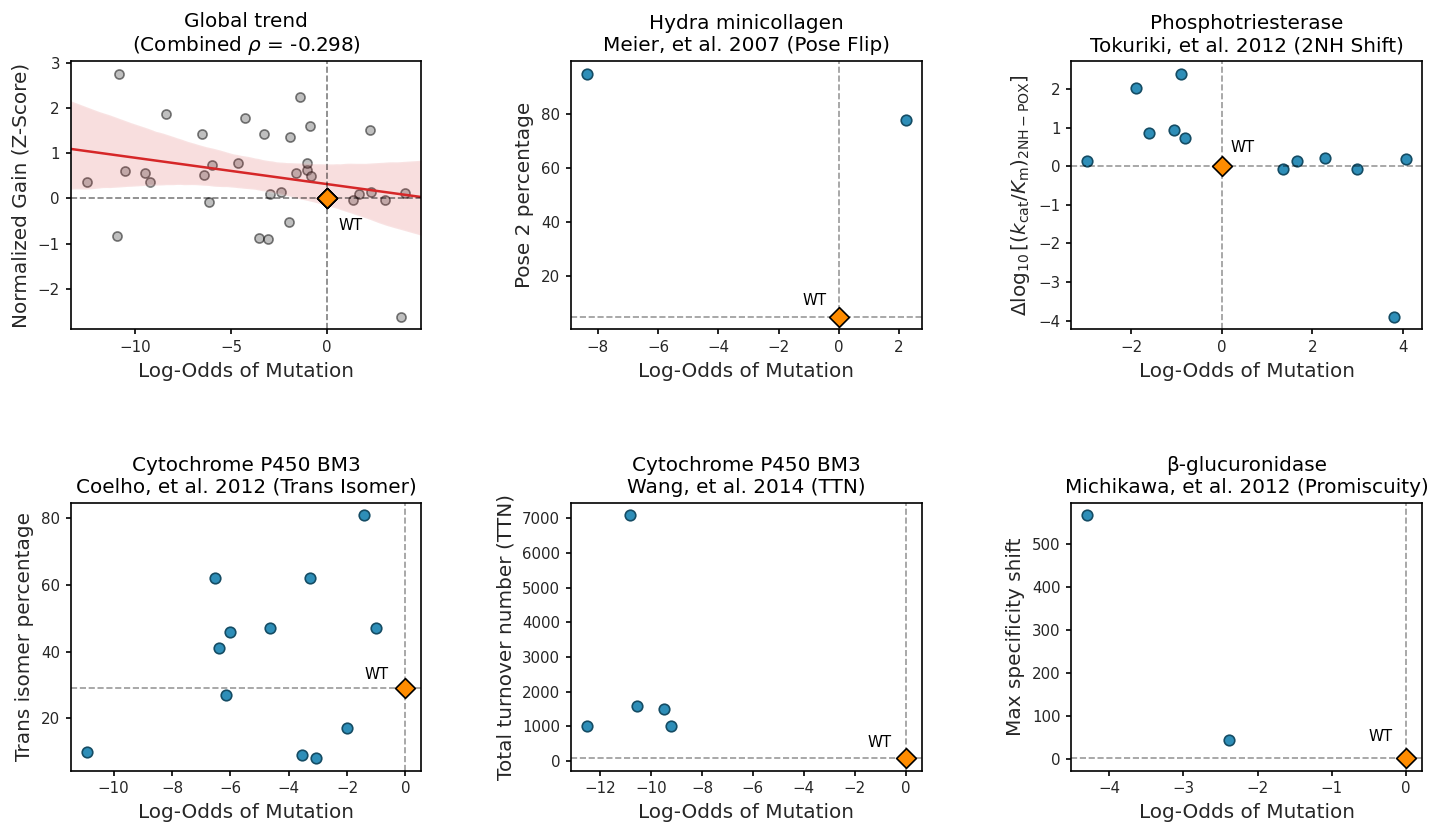

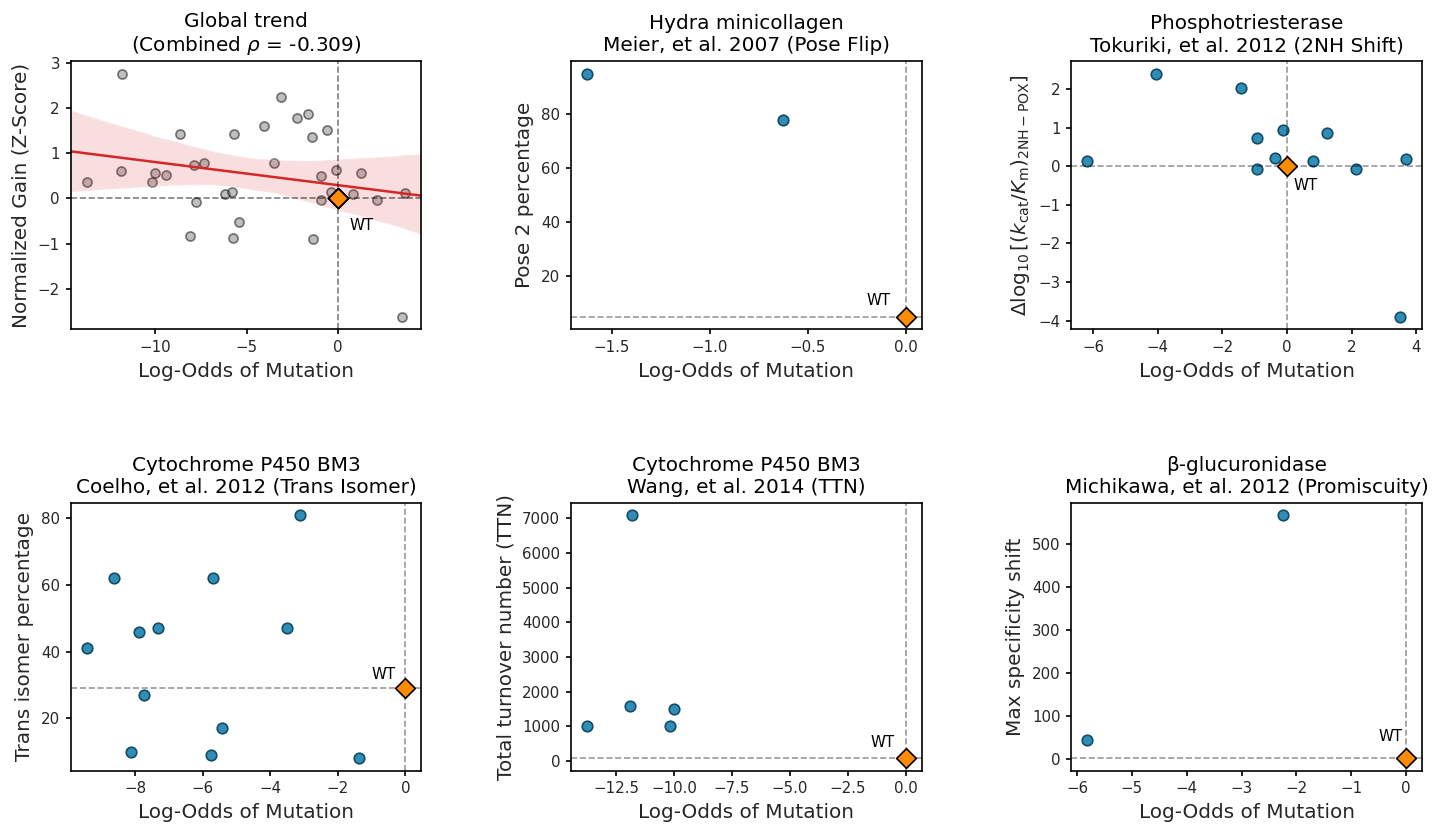

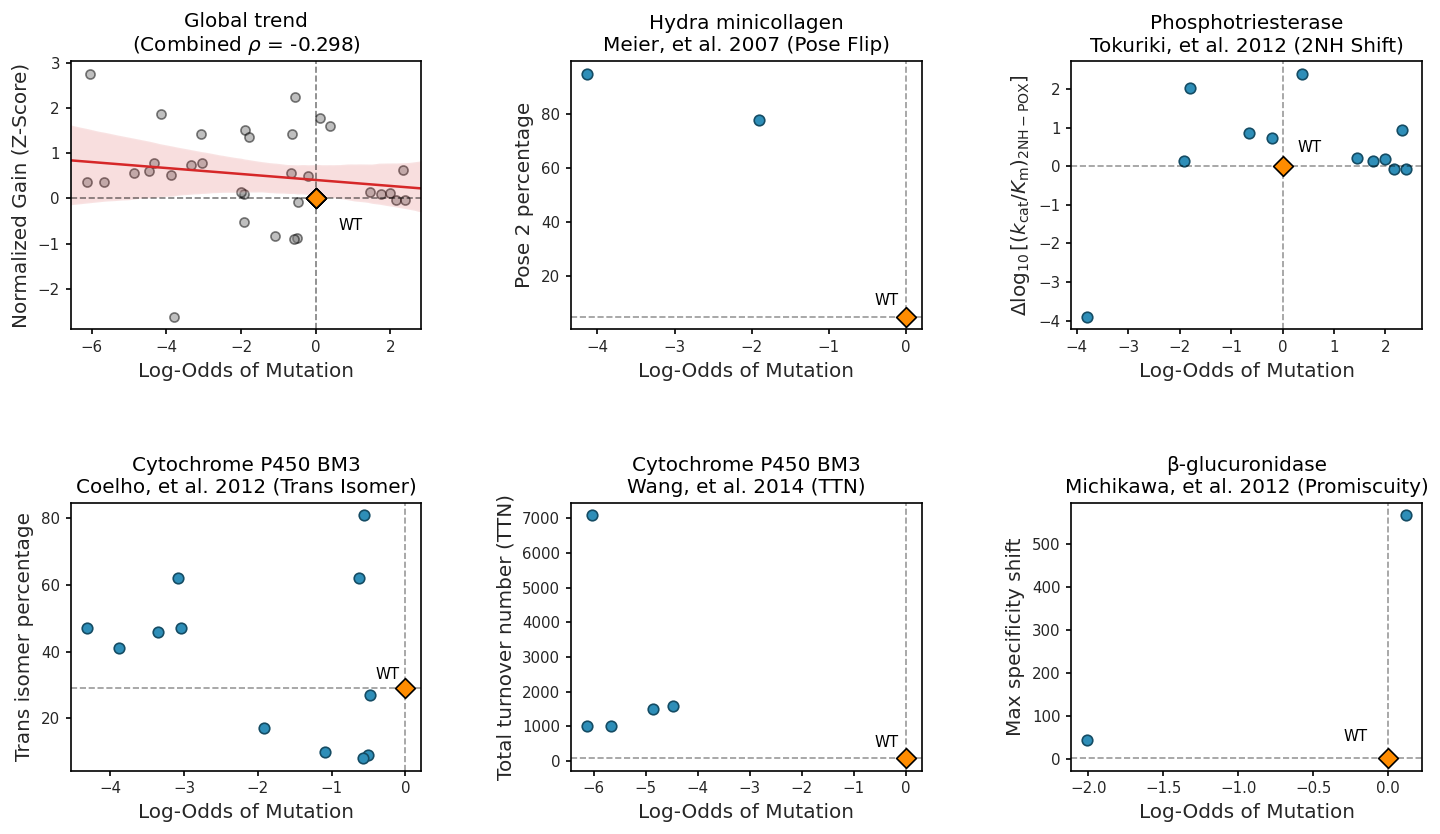

In [9]:
import matplotlib.ticker as ticker
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt


for model_name in ["ESM3_sm_open_v0.both", "esmc_600m", "protein_mpnn.proteinmpnn_v_48_020"]:

    fig5_df = pd.read_csv(repo_root / f"outputs/csvs/figure5_{model_name}_model_vs_experiment_long.csv")


    # --- Protein Name Dictionary ---
    protein_names = {
        "Meier, et al. 2007 (Pose Flip)": "Hydra minicollagen",
        "Tokuriki, et al. 2012 (2NH Shift)": "Phosphotriesterase",
        "Coelho, et al. 2012 (Trans Isomer)": "Cytochrome P450 BM3",
        "Wang, et al. 2014 (TTN)": "Cytochrome P450 BM3",
        "Michikawa, et al. 2012 (Promiscuity)": "β-glucuronidase"
    }

    # --- Styling Helper ---
    def apply_standard_style(ax):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1.0)
        ax.grid(False)
        # Ticks are present, black, and small (3pt)
        ax.tick_params(axis="both", which='major', labelsize=9, length=3, width=1, color='black', bottom=True, left=True)

    # --- Plotting Figure 5 (Global First) ---
    study_order = [
        "Meier, et al. 2007 (Pose Flip)",
        "Tokuriki, et al. 2012 (2NH Shift)",
        "Coelho, et al. 2012 (Trans Isomer)",
        "Wang, et al. 2014 (TTN)",
        "Michikawa, et al. 2012 (Promiscuity)",
    ]

    # Create a 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes_flat = axes.flatten()

    # 1. THE SUMMARY PLOT (Top Left / Index 0)
    ax_sum = axes_flat[0]
    # We've already computed 'exp_zscore' centered on WT.

    # Global scatter with a regression line to show the unified trend
    # For regression, don't include WT so it acts only on mutants, or include it? Usually include everything.
    sns.regplot(
        data=fig5_df[~fig5_df['is_wt']], 
        x="model_log_odds", 
        y="exp_zscore", 
        scatter_kws={'alpha':0.5, 's':30, 'color':'gray', 'edgecolor': 'black'}, 
        line_kws={'color':'#D62728', 'linewidth':1.5},
        ax=ax_sum,
        truncate=False
    )
    # Add WT to sum plot in orange
    wt_df = fig5_df[fig5_df['is_wt']]
    ax_sum.scatter(
        wt_df["model_log_odds"], 
        wt_df["exp_zscore"], 
        s=70, 
        marker='D',
        color="darkorange", 
        edgecolors="black", 
        linewidth=1,
        label='WT',
        zorder=5
    )

    # add text near WT point
    if not wt_df.empty:
        ax_sum.text(
            wt_df["model_log_odds"].iloc[0] + 0.6, 
            wt_df["exp_zscore"].iloc[0]-0.6, 
            "WT", 
            fontsize=9, 
            color="black", 
            verticalalignment='center'
        )

    global_rho = spearmanr(fig5_df["model_log_odds"], fig5_df["exp_zscore"]).correlation
    ax_sum.set_title(f"Global trend\n(Combined $\\rho$ = {global_rho:.3f})", fontsize=12, color='black')
    ax_sum.set_xlabel("Log-Odds of Mutation", fontsize=12)
    ax_sum.set_ylabel("Normalized Gain (Z-Score)", fontsize=12)
    ax_sum.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.5)
    ax_sum.axhline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.5)
    apply_standard_style(ax_sum)

    # 2. INDIVIDUAL STUDIES (Indices 1-5)
    for i, study in enumerate(study_order):
        ax = axes_flat[i + 1] # Offset by 1 to leave index 0 for the summary
        sub = fig5_df[fig5_df["study"] == study].copy()
        
        if sub.empty:
            ax.axis('off')
            continue
            
        sub_muts = sub[~sub['is_wt']]
        sub_wt = sub[sub['is_wt']]
        
        ax.scatter(sub_muts["model_log_odds"], sub_muts["exp_value"], s=40, alpha=1, color="#2E8EB8", edgecolors="#154C64", linewidth=1)
        
        # Study-specific rho in the title
        rho = spearmanr(sub["model_log_odds"], sub["exp_value"]).correlation
        ax.set_title(f"{protein_names.get(study, study)}\n{study}", fontsize=12, color='black')
        
        # Add WT in a distinct color and shape
        if not sub_wt.empty:
            ax.scatter(
                sub_wt["model_log_odds"], 
                sub_wt["exp_value"], 
                s=70,
                marker='D',
                color="darkorange", 
                edgecolors="black", 
                linewidth=1,
                zorder=5,
                label="WT"
            )
            if model_name == "ESM3_sm_open_v0.both":
                # add text near WT point
                if i == 0:  # For the first study, place text to the left of WT to avoid overlap with regression line
                    x_disp = -1.2
                    y_disp = 6
                elif i == 1:  # For the second study, place text above WT
                    x_disp = 0.2
                    y_disp = 0.5
                elif i == 2:  # For the third study, place text to the right of WT
                    x_disp = -1.4
                    y_disp = 4
                elif i == 3:  # For the fourth study, place text below WT
                    x_disp = -1.5
                    y_disp = 450
                else:  # For the last study, place text to the right of WT
                    x_disp = -0.5
                    y_disp = 50

            elif model_name == "esmc_600m":
                # add text near WT point
                if i == 0:  # For the first study, place text to the left of WT to avoid overlap with regression line
                    x_disp = -0.2
                    y_disp = 6
                elif i == 1:  # For the second study, place text above WT
                    x_disp = 0.2
                    y_disp = -0.5
                elif i == 2:  # For the third study, place text to the right of WT
                    x_disp = -1
                    y_disp = 4
                elif i == 3:  # For the fourth study, place text below WT
                    x_disp = -1.5
                    y_disp = 450
                else:  # For the last study, place text to the right of WT
                    x_disp = -0.5
                    y_disp = 50
            else:
                # add text near WT point
                if i == 0:  # For the first study, place text to the left of WT to avoid overlap with regression line
                    x_disp = -0.4
                    y_disp = 6
                elif i == 1:  # For the second study, place text above WT
                    x_disp = 0.3
                    y_disp = 0.5
                elif i == 2:  # For the third study, place text to the right of WT
                    x_disp = -0.4
                    y_disp = 4
                elif i == 3:  # For the fourth study, place text below WT
                    x_disp = -0.6
                    y_disp = 450
                else:  # For the last study, place text to the right of WT
                    x_disp = -0.3
                    y_disp = 50




            ax.text(
                sub_wt["model_log_odds"].iloc[0] + x_disp, 
                sub_wt["exp_value"].iloc[0] + y_disp, 
                "WT", 
                fontsize=9, 
                color="black", 
                verticalalignment='center'
            )
            # Check if 0 is in y axis range to draw hline at WT
            wt_y = sub_wt["exp_value"].iloc[0]
            ax.axhline(wt_y, color="black", linestyle="--", linewidth=1.0, alpha=0.4)
        else:
            # fallback if no WT
            pass

        ax.set_xlabel("Log-Odds of Mutation", fontsize=12)
        # replace Trans turnover number (TTN) with Total turnover number (TTN) in y-axis label for the specific study
        if "TTN" in sub["exp_axis_label"].iloc[0]:
            y_label = sub["exp_axis_label"].iloc[0].replace("Trans turnover number (TTN)", "Total turnover number (TTN)")
        else:
            y_label = sub["exp_axis_label"].iloc[0]
        ax.set_ylabel(y_label, fontsize=12)
        ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.4)
        
        apply_standard_style(ax)

    # Adjust layout to prevent label overlap
    fig.tight_layout(pad=2.5)

    # Assuming finalize_figure is defined elsewhere, but we might just save direct
    plt.savefig(fig5_out_dir / f"figure5_{model_name}_summary_first_grid.png", dpi=300, bbox_inches="tight")
    plt.show()

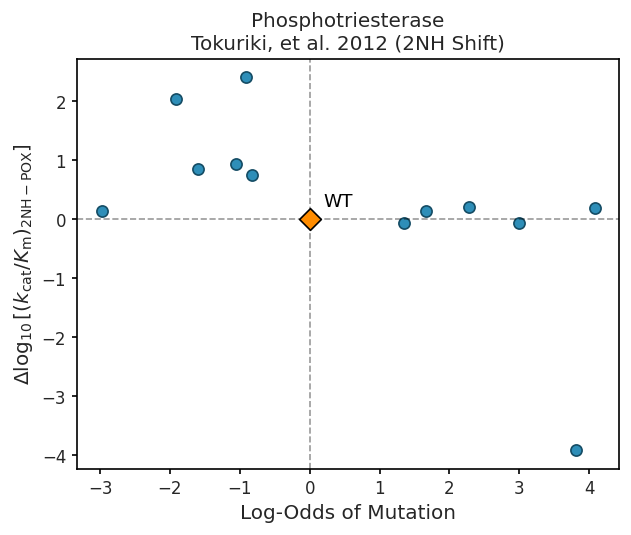

Tawfik-only WT-reference plot saved with 12 mutant points.


In [10]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# load the figure 5 data for the model of interest (e.g., ESM3_sm_open_v0.both)
model_name = "ESM3_sm_open_v0.both"
fig5_df = pd.read_csv(repo_root / f"outputs/csvs/figure5_{model_name}_model_vs_experiment_long.csv")

# Alternate Figure 5: Tawfik-only panel using WT-reference log-odds.
fig5_df_wt = fig5_df.copy()
tawfik_mask = (fig5_df_wt["study"] == "Tawfik 2012 (2NH Shift)") & (~fig5_df_wt["is_wt"])
if "model_log_odds_wt" not in fig5_df_wt.columns:
    raise KeyError("Expected model_log_odds_wt column not found. Re-run the Figure 5 data cell above.")

fig5_df_wt.loc[tawfik_mask, "model_log_odds"] = fig5_df_wt.loc[tawfik_mask, "model_log_odds_wt"].fillna(
    fig5_df_wt.loc[tawfik_mask, "model_log_odds"]
)

sub = fig5_df_wt[fig5_df_wt["study"] == "Tokuriki, et al. 2012 (2NH Shift)"].copy()
sub_muts = sub[~sub["is_wt"]]
sub_wt = sub[sub["is_wt"]]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.scatter(
    sub_muts["model_log_odds"],
    sub_muts["exp_value"],
    s=45,
    alpha=1,
    color="#2E8EB8",
    edgecolors="#154C64",
    linewidth=1,
)

if not sub_wt.empty:
    ax.scatter(
        sub_wt["model_log_odds"],
        sub_wt["exp_value"],
        s=85,
        marker="D",
        color="darkorange",
        edgecolors="black",
        linewidth=1,
        zorder=5,
        label="WT",
    )
    wt_x = sub_wt["model_log_odds"].iloc[0]
    wt_y = sub_wt["exp_value"].iloc[0]
    ax.text(wt_x + 0.2, wt_y + 0.3, "WT", fontsize=11, color="black", va="center")
    ax.axhline(wt_y, color="black", linestyle="--", linewidth=1.0, alpha=0.4)

rho = spearmanr(sub["model_log_odds"], sub["exp_value"]).correlation
ax.set_title(f"Phosphotriesterase\nTokuriki, et al. 2012 (2NH Shift)", fontsize=12)
ax.set_xlabel("Log-Odds of Mutation", fontsize=12)
ax.set_ylabel(r"$\Delta\log_{10}[(k_{\mathrm{cat}}/K_{\mathrm{m}})_{\mathrm{2NH-POX}}]$", fontsize=12)
ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.4)
ax.grid(False)
ax.tick_params(axis="both", which="major", labelsize=10, length=3, width=1, color="black", bottom=True, left=True)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

fig.tight_layout()
plt.savefig(fig5_out_dir / "figure5_tawfik_from_wt_only.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Tawfik-only WT-reference plot saved with {sub_muts.shape[0]} mutant points.")